# Trabalho Prático de Mineração de Dados — Fase 2
## Utilização de LLMs e Análise Comparativa com Diretrizes de IA Responsável

**Disciplina:** Mineração de Dados  
**Grupo:**

| Nome | Matrícula |
|---|---|
| Lucas Affonso Pires | 2023028420 |
| John Wesley Otaciano Costa | 2024014105 |
| Emmanuel Magalhães Figueiredo | 2024023821 |
| Bernardo Venancio Cunha Oliveira | 2023028684 |

**Dataset:** fifa_player_performance_market_value.csv  
**Tarefa de mineração:** Mineração de padrões frequentes e regras de associação  
**Data da entrega:** 03/05/2026

---

## Objetivo deste notebook

Este notebook documenta a Fase 2 do Trabalho Prático. O objetivo é usar uma ou mais LLMs como apoio à construção da solução de mineração de dados e comparar duas trilhas de interação:

- **Trilha A — baseline:** interação com a LLM sem explicitar diretrizes de IA responsável;
- **Trilha B — guiada:** interação com a LLM explicitando as diretrizes de IA responsável escolhidas pelo grupo.

O foco não é apenas mostrar prompts e respostas. O grupo deve analisar criticamente se a explicitação das diretrizes levou a diferenças concretas na solução proposta, por exemplo em:

- escolha de algoritmos;
- tratamento dos dados;
- seleção de atributos;
- definição de parâmetros;
- métricas de avaliação;
- interpretabilidade;
- privacidade;
- análise de viés;
- custo computacional;
- qualidade da documentação.

> **Importante:** este notebook é um modelo de estrutura. Ele contém exemplos, placeholders e código genérico. O grupo deve substituir os campos indicados por informações reais do seu dataset, das interações com LLMs e dos experimentos efetivamente realizados.


# Como usar este notebook

Este notebook foi organizado seguindo a estrutura esperada para a Fase 2:

1. **Business Understanding**
2. **Data Understanding & Data Preparation**
3. **Modeling**
4. **Evaluation**
5. **Checklist final**

Ao longo do notebook, os trechos marcados entre colchetes, como `[INSERIR LINK DA CONVERSA]`, devem ser preenchidos pelo grupo.

## Diferença entre exemplo e entrega real

- Células de **exemplo** mostram como organizar a entrega.
- Células com **placeholders** indicam pontos que devem ser preenchidos.
- Células de **código** são genéricas e podem precisar de adaptação ao dataset.
- Nenhum resultado experimental deve ser inventado.
- Toda conclusão empírica deve estar apoiada em uma tabela, gráfico ou execução de código.


# 0. Controle da entrega e rastreabilidade

Esta seção registra informações mínimas para tornar o trabalho rastreável e auditável.

| Item | Valor |
|---|---|
| Nome do dataset | fifa_player_performance_market_value.csv |
| Link público do dataset | https://www.kaggle.com/datasets/itszubi/fifa-player-performance-and-market-value |
| Número de linhas | 2800 |
| Número de colunas | 16 |
| Tarefa de mineração | Mineração de padrões frequentes e regras de associação para identificar perfis associados a valor de mercado e risco de transferência |
| LLM usada na Trilha A | Gemini Pro |
| LLM usada na Trilha B | Gemini Pro |
| Link da conversa — Trilha A | https://gemini.google.com/share/0bd7f65d5217 |
| Link da conversa — Trilha B | https://gemini.google.com/share/55b14333b4ee |

## Diretrizes de IA responsável escolhidas

| Diretriz | Justificativa da escolha | Como será explicitada na Trilha B |
|---|---|---|
| Justiça e Viés | Garantir a neutralidade técnica ao mitigar vieses geográficos e preconceitos históricos que supervalorizam atletas de certas nacionalidades, focando exclusivamente em métricas universais de desempenho. | Como um filtro ético e técnico obrigatório, estabelecendo que a nacionalidade não deve ser tratada como um preditor de valor para evitar que o modelo automatize preconceitos históricos. |
|  Explicabilidade | Necessidade de transformar métricas estatísticas complexas em conhecimento prático e auditável para gestores esportivos, garantindo que os resultados utilizem a linguagem do futebol e sejam facilmente compreendidos para apoiar decisões estratégicas de alto investimento. | Como um pilar de utilidade prática, exigindo que o modelo abandone a complexidade de "caixa-preta" para utilizar a linguagem do futebol através da discretização semântica, garantindo que os padrões extraídos sejam intuitivos, auditáveis e diretamente aplicáveis na tomada de decisão estratégica dos gestores do clube. |

> **Propósito pedagógico:** esta seção evita que a análise fique solta ou apenas narrativa. O avaliador precisa conseguir identificar o que foi perguntado à LLM, quando, em qual modelo e com qual objetivo.


In [18]:
# Configurações iniciais do notebook
# Esta célula centraliza imports e parâmetros gerais.
# O grupo deve adaptar os caminhos, nomes de colunas e tipo de tarefa.

import os
import time
import json
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Caminho para o dataset.
# Exemplos:
# DATA_PATH = "dados/dataset.csv"
# DATA_PATH = "/content/dataset.csv"
DATA_PATH = "../fifa_player_performance_market_value.csv"

# Tipo de tarefa do TP.
# Opções sugeridas:
# - "padroes_frequentes"
# - "agrupamento"
# - "classificacao"
TASK_TYPE = "Padrões Frequentes"

# Coluna-alvo, se aplicável.
# Para padrões frequentes ou agrupamento, normalmente pode ser None.
TARGET_COLUMN = None  # Exemplo: "classe"

# Coluna ou conjunto de colunas usadas para gerar transações, se o TP for de padrões frequentes.
TRANSACTION_COLUMN = "[INSERIR_COLUNA_DE_TRANSACOES]"

print("Configuração carregada.")
print(f"Tarefa definida: {TASK_TYPE}")


Configuração carregada.
Tarefa definida: Padrões Frequentes


# 1. Business Understanding

Nesta seção, o grupo deve explicar o problema, o contexto dos dados, a relevância da tarefa e a hipótese experimental sobre o uso das diretrizes de IA responsável.

A seção deve responder:

1. Qual problema será investigado?
2. Por que o dataset é relevante?
3. Qual tarefa de mineração de dados será executada?
4. Qual é o valor esperado da análise?
5. Quais diretrizes de IA responsável foram escolhidas?
6. Por que essas diretrizes são pertinentes ao problema?
7. O que se espera que mude quando essas diretrizes são explicitadas à LLM?


## 1.1 Descrição do problema de negócio

O mercado de transferências no futebol profissional envolve decisões de alto custo e alto risco. Clubes precisam avaliar, com antecedência, quais perfis de jogadores tendem a apresentar maior valor de mercado e quais características estão associadas a níveis distintos de risco de transferência. Nesse contexto, a mineração de dados pode apoiar a descoberta de padrões relevantes em atributos esportivos, contratuais e físicos dos atletas, transformando dados brutos em conhecimento útil para a tomada de decisão.

- **Contexto:** clubes e departamentos de scouting precisam justificar contratações, renovações e investimentos com base em evidências, e não apenas em percepção subjetiva ou reputação de mercado.
- **Problema:** identificar combinações de características de jogadores que estejam associadas a diferentes faixas de valor de mercado e níveis de risco de transferência.
- **Possíveis interessados:** analistas de desempenho, departamentos de scouting, gestores esportivos e diretorias responsáveis por contratações.
- **Decisões apoiadas pela análise:** priorização de perfis de jogadores para observação, identificação de atletas potencialmente supervalorizados ou subvalorizados e avaliação de fatores que aumentam ou reduzem o risco de uma negociação.
- **Limitações iniciais conhecidas:** o dataset representa um recorte estático dos jogadores, não incorpora contexto temporal e pode não capturar fatores externos importantes para o mercado, como pressão midiática, histórico detalhado de lesões, influência de empresários ou contexto financeiro dos clubes.

Assim, o objetivo do trabalho é extrair regras de associação interpretáveis que ajudem a explicar como atributos de desempenho, idade, contrato e condição física se relacionam com valor de mercado e risco de transferência.

> Este texto deve ser escrito pelo grupo. Não copie a descrição do dataset sem contextualizar o problema de mineração de dados.


## 1.2 Objetivo do dataset, origem e características gerais

### Objetivo do dataset

O dataset foi utilizado para analisar padrões associados ao valor de mercado e ao risco de transferência de jogadores de futebol profissional. Seu propósito, no contexto deste trabalho, é permitir a aplicação de técnicas de mineração de padrões frequentes e regras de associação sobre atributos esportivos, físicos, contratuais e demográficos dos atletas, de modo a identificar combinações recorrentes que possam apoiar decisões de scouting e avaliação de mercado.

### Origem dos dados

O dataset foi derivado de fontes públicas de dados de futebol e posteriormente passou por etapas de limpeza, combinação e enriquecimento para fins analíticos. Além disso, alguns atributos, como valor de mercado e risco de transferência, foram feitos com engenharia para fins educacionais. Por isso, a base não deve ser interpretada como um retrato bruto e integral do mercado real, mas como um conjunto estruturado para experimentação em mineração de dados.

Link público: https://www.kaggle.com/datasets/itszubi/fifa-player-performance-and-market-value

### Características do dataset

| Coluna | Tipo esperado | Descrição | Relevância para a tarefa |
|---|---|---|---|
| age | Numérico discreto | Idade do jogador | Permite identificar padrões ligados ao estágio de carreira |
| nationality | Categórico | Nacionalidade do jogador | Pode introduzir viés e por isso exige cuidado metodológico |
| club | Categórico | Clube atual do jogador | Ajuda a contextualizar o atleta, mas pode gerar alta especificidade |
| position | Categórico | Posição do jogador em campo | Importante para interpretar diferenças de desempenho e perfil |
| overall_rating | Numérico discreto | Avaliação geral atual do jogador | Indicador central de qualidade esportiva |
| potential_rating | Numérico discreto | Potencial estimado do jogador | Relevante para associar valor futuro e perfil de investimento |
| matches_played | Numérico discreto | Número de partidas jogadas | Indica participação competitiva do atleta |
| goals | Numérico discreto | Número de gols marcados | Mede contribuição ofensiva |
| assists | Numérico discreto | Número de assistências | Mede contribuição criativa/ofensiva |
| minutes_played | Numérico discreto | Total de minutos jogados | Complementa a análise de participação em campo |
| market_value_million_eur | Numérico contínuo | Valor de mercado estimado em milhões de euros | Uma das variáveis-alvo da análise |
| contract_years_left | Numérico discreto | Tempo restante de contrato | Variável importante para explicar risco e valor de negociação |
| injury_prone | Categórico binário | Indica propensão a lesões | Relevante para análise de risco |
| transfer_risk_level | Categórico ordinal | Nível de risco associado à transferência | Segunda variável-alvo da análise |


### Relação com o problema de negócio

O dataset é adequado para o problema proposto porque reúne atributos técnicos, físicos, contratuais e demográficos que ajudam a caracterizar perfis de jogadores sob a perspectiva de mercado. Embora parte da base tenha sido enriquecida com atributos para fins educacionais, ela mantém utilidade para a descoberta de padrões interpretáveis entre desempenho, valor de mercado e risco de transferência, o que é compatível com os objetivos deste trabalho.


## 1.3 Diretrizes selecionadas e hipótese experimental

### Diretrizes selecionadas

| Diretriz | Por que é pertinente ao problema? | Possível efeito esperado na solução da LLM |
|---|---|---|
| Justiça e Viés | O atributo nationality presente no dataset é um ponto crítico de viés histórico no futebol, onde atletas de determinadas regiões podem ser supervalorizados independentemente de suas estatísticas de desempenho. Se o algoritmo for alimentado diretamente com essa coluna, ele pode "aprender" o preconceito do mercado e gerar regras discriminatórias que não refletem a qualidade técnica do atleta. | A LLM deve sugerir a remoção do atributo nationality como preditor direto ou seu agrupamento em regiões amplas para evitar que o país de origem dite o valor do jogador. O modelo será forçado a buscar suporte em atributos de performance (overall_rating, potential_rating, injury_prone), garantindo que a regra resultante seja tecnicamente justa e baseada no que o jogador entrega em campo. |
| Explicabilidade | O dataset contém variáveis contínuas (como age, market_value_million_eur e minutes_played) que, se mantidas em formato numérico, impedem a aplicação de algoritmos de mineração de padrões frequentes como o FP-Growth. Além disso, a tarefa exige que o resultado seja acionável para um departamento de scouting, onde uma regra técnica precisa ser traduzida em conceitos esportivos. | A LLM deverá transformar dados brutos em labels com significado real, como age_promessa, status_titular ou valor_elite. A solução deverá incluir ressalvas de que a alta confiança em uma regra indica apenas coocorrência histórica, evitando que gestores interpretem correlação como causalidade direta. |

### Hipótese experimental

Esperamos que, ao explicitar as diretrizes de Explicabilidade e Justiça e Viés, a LLM proponha uma solução com maior interpretabilidade semântica e maior cuidado com atributos sensíveis, em comparação com a solução baseline.

Exemplo de formulação:

> Esperamos que, ao explicitar as diretrizes de [DIRETRIZ 1] e [DIRETRIZ 2], a LLM proponha uma solução com [MAIOR INTERPRETABILIDADE / MELHOR RASTREABILIDADE / MAIOR CUIDADO COM ATRIBUTOS SENSÍVEIS / MÉTRICAS MAIS ADEQUADAS / MENOR CUSTO COMPUTACIONAL], em comparação com a solução baseline.

### Evidências que serão analisadas

Para avaliar a hipótese, compararemos as trilhas quanto a:

- algoritmos sugeridos;
- etapas de preparação dos dados;
- parâmetros recomendados;
- métricas propostas;
- justificativas técnicas;
- riscos apontados;
- limitações reconhecidas;
- aderência às diretrizes escolhidas.


## 1.4 Interações com LLM — Business Understanding

### Trilha A — baseline

**Modelo utilizado:** Gemini Pro  
**Data de acesso:** 29/04/2026  
**Link da conversa:** https://gemini.google.com/share/0bd7f65d5217  
**Subtarefa:** obter apoio para formular o Business Understanding.

#### Prompt principal — baseline

```text
Estou fazendo um trabalho de Mineração de Dados com o dataset fifa_player_performance_market_value.

A tarefa é encontrar correlações entre as caracteristicas dos jogadores que apresente padrões acerca das colunas de valor de mercado e risco de transferencia.

Ajude-me a formular o Business Understanding. Além da descrição do problema, indique riscos, limitações e critérios que deveriam

orientar a solução de mineração de dados.  
```

#### Síntese da resposta da LLM

#### Entendimento do projeto

```text
O problema central que a mineração de dados visa resolver é a precificação inadequada e a exposição ao risco. O objetivo do projeto é modelar essas dinâmicas, permitindo a descoberta de padrões que identifiquem jogadores subvalorizados no mercado ou que sinalizem contratações de alto risco.
```

#### Entendimento dos riscos

```text
Viés de Posição (Position Bias): Jogadores de ataque (ST, LW, RW) tradicionalmente têm valores de mercado maiores do que defensores e estatísticas de gols/assistências infladas. Se o modelo não segmentar ou normalizar os dados pela coluna position, ele corre o risco de penalizar injustamente jogadores defensivos.

Overfitting em Estrelas (Outliers): O mercado de futebol possui valores extremos (jogadores de classe mundial que custam centenas de milhões). Há o risco de o algoritmo focar demais em tentar explicar esses "pontos fora da curva", prejudicando a generalização para o restante da base.

Multicolinearidade Analítica: Variáveis como overall_rating e potential_rating, ou matches_played e minutes_played, costumam apresentar altíssima correlação entre si. Isso pode desestabilizar alguns modelos matemáticos lineares ou mascarar a importância real de atributos isolados.
```

#### Limitações do dataset

```text
Escopo Estatístico Básico: Os dados fornecem métricas clássicas (goals, assists, minutes_played), mas carecem de estatísticas avançadas granulares utilizadas no futebol moderno (como Expected Goals - xG, progressão de bola, ou desarmes no terço ofensivo).

Corte Temporal (Snapshot): O dataset representa uma fotografia estática do desempenho dos atletas em um determinado momento. Como não há séries temporais, fica impossível aplicar modelos de regressão que avaliem a consistência de um jogador ao longo de múltiplas temporadas ou sua curva histórica de evolução técnica.

Fatores Externos: O valor de mercado no mundo real também é ditado por marketing, carisma, nacionalidade, necessidade iminente do clube comprador e inflação geral do mercado esportivo, variáveis difíceis de capturar totalmente apenas com os atributos disponíveis.
```

#### Solução

```text
Regressão: Para a predição contínua de market_value_million_eur (buscando minimizar erros absolutos e entender o peso de atributos como idade vs. potencial).

Classificação ou Associação: Para o transfer_risk_level (variável categórica). A aplicação de técnicas de mineração de regras de associação (como algoritmos da família FP-Growth) é altamente recomendada aqui para extrair padrões lógicos ocultos.
```

---

### Trilha B — guiada por diretrizes

**Modelo utilizado:** Gemini Pro  
**Data de acesso:** 02/05/2026  
**Link da conversa:** https://gemini.google.com/share/55b14333b4ee  
**Subtarefa:** obter apoio para formular o Business Understanding considerando as diretrizes escolhidas.

#### Prompt principal — guiado

```text
Estou fazendo um trabalho de Mineração de Dados com o dataset fifa_player_performance_market_value.

A tarefa é encontrar correlações entre as caracteristicas dos jogadores que apresente padrões acerca das colunas de valor de mercado e risco de transferencia.

Ajude-me a formular o Business Understanding. Além da descrição do problema, indique riscos, limitações e critérios que deveriam

orientar a solução de mineração de dados.  

Considere explicitamente as seguintes diretrizes de IA responsável:

Explicabilidade: O problema exige que os atributos contínuos sejam discretizados gerando faixas com significado esportivo real (ex: transformar idades numéricas em "Promessa", "Veterano", etc.). Além disso, a interpretação dos padrões encontrados deve ser clara e conter ressalvas explícitas de que regras de associação não implicam relações causais.

Justiça e Viés: O dataset possui atributos demográficos que precisam de atenção, como a nacionalidade (nationality). A análise deve evitar ativamente a formulação ou valorização de regras que reforcem estereótipos ou correlações enviesadas, como associar o valor financeiro do jogador puramente ao seu país de origem.

Além da descrição do problema, indique riscos, limitações e critérios que deveriam
orientar a solução de mineração de dados.
```

#### Síntese da resposta da LLM

#### Descrição do Problema (Business Objective) 

```text
Contexto: O mercado de transferências é complexo, volátil e de alto risco financeiro.  

Propósito: Descobrir padrões e correlações entre desempenho, dados biográficos e valor de mercado.  

Aplicação: Servir como ferramenta de suporte à decisão para departamentos de scouting (como o do Atlético-MG), justificando investimentos e identificando jogadores subvalorizados ou de risco.
```

#### Diretrizes de IA Responsável e Modelagem - Para que a análise seja ética e acionável no mundo esportivo, a modelagem deve seguir critérios rigorosos

```text
Explicabilidade: O modelo deve "falar a língua do esporte", transformando números brutos em categorias lógicas como "Promessa", "Auge" ou "Titular Absoluto".  

Causalidade vs. Correlação: O projeto deve deixar claro que as regras identificam coocorrência histórica, e não relações de causa e efeito (evitando conclusões simplistas sobre o valor dos atletas).  

Justiça (Fairness): Mitigar o viés de nacionalidade. O país de origem não deve ser usado como preditor de valor para evitar a perpetuação de preconceitos históricos do mercado.
```

#### Riscos e Limitações do ProjetoViés de Sobrevivência

```text
Viés de Sobrevivência: Os dados focam em profissionais bem-sucedidos, podendo não se aplicar a jogadores da base.  

Falta de Contexto: Estatísticas puras podem ignorar a "inteligência de jogo" que não é traduzida em números (ex: posicionamento defensivo).  

Fatores Externos: O valor de mercado depende de variáveis fora do dataset, como tempo de contrato, lesões e poder de negociação de empresários.
```

#### Critérios de Sucesso (Data Mining Goals)

```text
Regras Robustas: Utilizar algoritmos como Apriori ou FP-Growth com limiares mínimos de Suporte e Confiança.  

Métrica de Lift: Garantir um Lift significativamente maior que 1.0 para provar que as associações não são aleatórias.  

Acessibilidade: Produzir insights e visualizações compreensíveis para profissionais do futebol que não são cientistas de dados.
```


## 1.5 Análise crítica das trilhas — Business Understanding

| Critério | Trilha A — baseline | Trilha B — guiada | Diferença observada |
|---|---|---|---|
| Clareza do problema | Muito boa, entendimento completo com adição de fatores fora do dataset. | Muito boa, com formulação igualmente clara e já conectada ao uso prático para scouting e suporte à decisão. | As duas trilhas compreenderam bem o problema, mas a Trilha B apresentou o contexto de aplicação de forma mais alinhada ao uso final da análise. |
| Relação com o dataset | Muito boa, apresentou limitações e riscos reais ao trabalhar com o dataset. | É igualmente boa, soube reconhecer as limitações do dataset e riscos também | A trilha B foi mais simplória na análise, o resultado da primeira foi mais completo e relevante pro problema |
| Consideração das diretrizes | Houveram menções ao risco de enviesar o projeto com jogadores estrelas ou posições específicas no futebol | Considerou explicitamente explicabilidade, causalidade versus correlação e mitigação de viés de nacionalidade. | A principal diferença foi que a Trilha B incorporou diretamente as diretrizes como parte do raciocínio metodológico. |
| Identificação de riscos | Muito boa, apresentou um cuidado real com as condições do dataset | Muito boa, acrescentando riscos relacionados à interpretação prática e ao uso ético dos atributos. | A Trilha B ampliou o escopo dos riscos ao incluir preocupações éticas e de interpretabilidade, além das técnicas. |
| Qualidade da justificativa | Muito boa, com argumentos sólidos e plausíveis | Igualmente boa | A diferença é que a trilha B construiu sua argumentação guiada muito nas diretrizes pedidas |
| Erros ou omissões | Nenhum erro ou omissão | Sem erros graves ou omissoes | Neste quesito se mostraram equivalentes |

### Síntese crítica

As duas trilhas foram úteis para construir o Business Understanding e, no geral, ambas entenderam corretamente o problema de mineração envolvendo valor de mercado e risco de transferência. A Trilha A se destacou mais na relação com o dataset em si, trazendo limitações e riscos mais conectados diretamente ao problema e às características da base.

Já a Trilha B teve como principal diferencial o fato de incorporar explicitamente as diretrizes de IA responsável no raciocínio. Isso deixou a resposta mais alinhada com a proposta da atividade, especialmente ao tratar explicabilidade, causalidade versus correlação e viés ligado à nacionalidade. Assim, a Trilha A foi mais completa em alguns aspectos técnicos do problema, enquanto a Trilha B foi mais aderente às diretrizes metodológicas exigidas pela Fase 2.


# 2. Data Understanding & Data Preparation

Nesta seção, o grupo deve explorar o dataset, identificar problemas de qualidade dos dados e preparar os dados para a etapa de modelagem.

Além disso, deve registrar como a LLM foi usada para apoiar:

- exploração inicial;
- identificação de problemas;
- tratamento de valores ausentes;
- transformação de atributos;
- seleção de variáveis;
- preparação específica para a tarefa de mineração;
- identificação de aspectos relacionados às diretrizes de IA responsável.


In [19]:
# Carregamento do dataset
# Esta célula deve ser adaptada de acordo com o formato do arquivo.

def carregar_dataset(caminho: str) -> pd.DataFrame:
    # Carrega um dataset a partir de um arquivo CSV, Excel, JSON ou Parquet.
    # Adapte esta função se o dataset estiver em outro formato.
    # if caminho == "../fifa_player_performance_market_value.csv":
    #     raise ValueError("Substitua DATA_PATH pelo caminho real do dataset.")

    caminho_path = Path(caminho)

    if not caminho_path.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {caminho_path.resolve()}")

    if caminho_path.suffix.lower() == ".csv":
        return pd.read_csv(caminho_path)
    elif caminho_path.suffix.lower() in [".xlsx", ".xls"]:
        return pd.read_excel(caminho_path)
    elif caminho_path.suffix.lower() == ".json":
        return pd.read_json(caminho_path)
    elif caminho_path.suffix.lower() == ".parquet":
        return pd.read_parquet(caminho_path)
    else:
        raise ValueError("Formato não tratado neste modelo. Adapte a função carregar_dataset.")

# Exemplo de uso:
df = carregar_dataset(DATA_PATH)
print("Dataset carregado com sucesso.")
print(f"Número de linhas: {df.shape[0]}")
print(f"Número de colunas: {df.shape[1]}")
display(df.head())


Dataset carregado com sucesso.
Número de linhas: 2800
Número de colunas: 16


,player_id,player_name,age,nationality,club,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level
0,1,Player_1,23,Germany,Liverpool,ST,65,87,8,6,14,2976,122.51,3,No,Low
1,2,Player_2,36,England,FC Barcelona,ST,90,76,19,3,18,2609,88.47,5,No,High
2,3,Player_3,31,France,Juventus,RB,75,91,34,12,15,1158,20.24,3,No,Medium
3,4,Player_4,27,Portugal,Manchester City,LW,90,86,35,18,13,145,164.29,0,Yes,Medium
4,5,Player_5,24,Brazil,Liverpool,CDM,84,96,41,6,6,2226,121.34,4,No,Low


In [21]:
# Verificação mínima das restrições do dataset
# A especificação exige dataset público, com pelo menos 1000 linhas e 4 colunas.
# O link público deve ser documentado em Markdown; aqui validamos apenas dimensões.

def verificar_restricoes_dataset(df: pd.DataFrame) -> None:
    n_linhas, n_colunas = df.shape

    print("Verificação das dimensões do dataset")
    print(f"- Linhas: {n_linhas}")
    print(f"- Colunas: {n_colunas}")

    if n_linhas < 1000:
        print("ATENÇÃO: o dataset possui menos de 1000 linhas.")
    else:
        print("OK: o dataset possui pelo menos 1000 linhas.")

    if n_colunas < 4:
        print("ATENÇÃO: o dataset possui menos de 4 colunas.")
    else:
        print("OK: o dataset possui pelo menos 4 colunas.")

# Executar após carregar o dataset:
verificar_restricoes_dataset(df)


Verificação das dimensões do dataset
- Linhas: 2800
- Colunas: 16
OK: o dataset possui pelo menos 1000 linhas.
OK: o dataset possui pelo menos 4 colunas.


In [22]:
# Exploração inicial
# Esta célula gera uma visão geral do dataset.
# O grupo deve interpretar os resultados em uma célula Markdown logo abaixo.

def resumo_inicial(df: pd.DataFrame) -> pd.DataFrame:
    resumo = pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "n_nulos": df.isna().sum(),
        "perc_nulos": (df.isna().mean() * 100).round(2),
        "n_unicos": df.nunique(dropna=True)
    })

    return resumo.sort_values(by="perc_nulos", ascending=False)

# Exemplo de uso:
resumo = resumo_inicial(df)
display(resumo)


,tipo,n_nulos,perc_nulos,n_unicos
player_id,int64,0,0.0,2800
player_name,object,0,0.0,2800
age,int64,0,0.0,23
nationality,object,0,0.0,8
club,object,0,0.0,7
position,object,0,0.0,9
overall_rating,int64,0,0.0,35
potential_rating,int64,0,0.0,34
matches_played,int64,0,0.0,55
goals,int64,0,0.0,40


In [23]:
# Estatísticas descritivas
# O objetivo é separar análise de variáveis numéricas e categóricas.

def estatisticas_descritivas(df: pd.DataFrame):
    numericas = df.select_dtypes(include=np.number)
    categoricas = df.select_dtypes(exclude=np.number)

    print("Colunas numéricas:", list(numericas.columns))
    print("Colunas não numéricas:", list(categoricas.columns))

    if len(numericas.columns) > 0:
        print("\nEstatísticas descritivas — variáveis numéricas")
        display(numericas.describe().T)

    if len(categoricas.columns) > 0:
        print("\nEstatísticas descritivas — variáveis categóricas/textuais")
        display(categoricas.describe().T)

# Exemplo de uso:
estatisticas_descritivas(df)


Colunas numéricas: ['player_id', 'age', 'overall_rating', 'potential_rating', 'matches_played', 'goals', 'assists', 'minutes_played', 'market_value_million_eur', 'contract_years_left']
Colunas não numéricas: ['player_name', 'nationality', 'club', 'position', 'injury_prone', 'transfer_risk_level']

Estatísticas descritivas — variáveis numéricas


,count,mean,std,min,25%,50%,75%,max
player_id,2800.0,1400.500000,808.434702,1.00,700.750,1400.50,2100.2500,2800.00
age,2800.0,27.952500,6.750192,17.00,22.000,28.00,34.0000,39.00
overall_rating,2800.0,76.866786,9.921113,60.00,68.000,77.00,85.0000,94.00
potential_rating,2800.0,81.563929,9.755799,65.00,73.000,82.00,90.0000,98.00
matches_played,2800.0,27.135714,15.979627,0.00,13.750,27.00,41.0000,54.00
goals,2800.0,19.261786,11.567858,0.00,9.000,19.00,30.0000,39.00
assists,2800.0,12.015000,7.188459,0.00,6.000,12.00,18.0000,24.00
minutes_played,2800.0,2250.101429,1295.461829,0.00,1131.250,2251.00,3366.2500,4497.00
market_value_million_eur,2800.0,90.565500,52.078881,0.67,45.355,89.17,136.6825,179.96
contract_years_left,2800.0,2.527857,1.699445,0.00,1.000,3.00,4.0000,5.00



Estatísticas descritivas — variáveis categóricas/textuais


,count,unique,top,freq
player_name,2800,2800,Player_2800,1
nationality,2800,8,Brazil,380
club,2800,7,Juventus,439
position,2800,9,ST,329
injury_prone,2800,2,No,2125
transfer_risk_level,2800,3,Low,1250


## 2.1 Exploração inicial — interpretação

A exploração inicial mostrou que o dataset possui 2800 linhas e 16 colunas, atendendo com folga ao requisito mínimo de volume para a atividade. A base combina atributos numéricos e categóricos, o que é compatível com a proposta do trabalho, já que a tarefa exige transformar características dos jogadores em itens interpretáveis para mineração de padrões frequentes.

Em relação aos tipos de dados, as variáveis numéricas concentram informações de idade, desempenho, participação em jogos, valor de mercado e situação contratual, enquanto as variáveis categóricas representam identidade, contexto esportivo e fatores de risco. Não foram observados valores ausentes em nenhuma coluna, o que simplifica a etapa inicial de preparação e evita a necessidade de imputação.

A análise também mostrou que algumas colunas possuem alta cardinalidade ou comportamento de identificador. Os atributos player_id e player_name têm 2800 valores únicos cada, o que indica que funcionam como identificadores individuais e não devem contribuir para a descoberta de padrões gerais. Já variáveis como minutes_played e market_value_million_eur apresentam muitos valores distintos, o que reforça a necessidade de discretização antes da aplicação de algoritmos como Apriori ou FP-Growth.

Entre as variáveis categóricas, nationality, club e position são potencialmente relevantes para a análise, mas exigem cuidado. A coluna nationality, em especial, merece atenção por poder introduzir vieses indevidos na interpretação dos padrões, já que o país de origem não deve ser tratado automaticamente como indicativo de valor ou risco esportivo. Por outro lado, colunas como overall_rating, potential_rating, contract_years_left, injury_prone e transfer_risk_level são diretamente relevantes para a tarefa, pois ajudam a caracterizar perfis de jogadores sob a ótica de desempenho, valorização e risco de negociação.

Uma limitação inicial percebida é que o dataset, embora estruturado e útil para experimentação, não representa um retrato bruto do mercado real, já que parte dos atributos foi enriquecida ou criada para fins educacionais. Isso exige cuidado na interpretação dos resultados, principalmente para evitar conclusões excessivamente fortes sobre causalidade ou aplicabilidade direta ao futebol profissional real.



### Relação com as diretrizes escolhidas

A exploração inicial já mostra relação direta com as diretrizes de Justiça e Viés e Explicabilidade. Do ponto de vista de justiça e viés, a presença da coluna nationality exige atenção especial, pois ela pode induzir regras enviesadas caso seja utilizada sem critério. Do ponto de vista de explicabilidade, a alta cardinalidade de variáveis numéricas e contínuas indica que será necessário transformá-las em faixas semânticas mais compreensíveis, como categorias de idade, nível técnico ou perfil contratual, para que as regras geradas façam sentido para interpretação humana e para o contexto do problema.


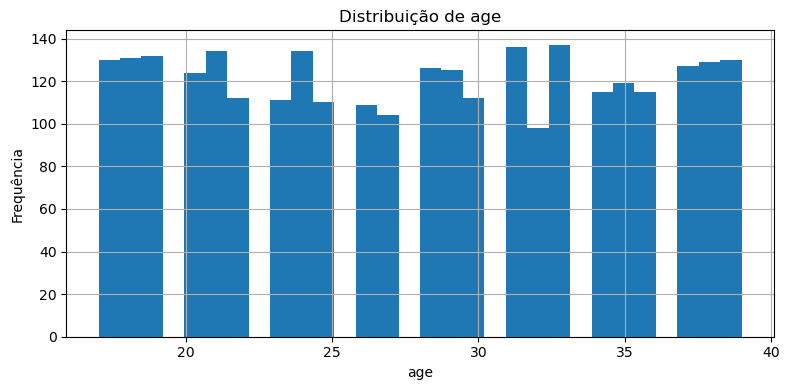

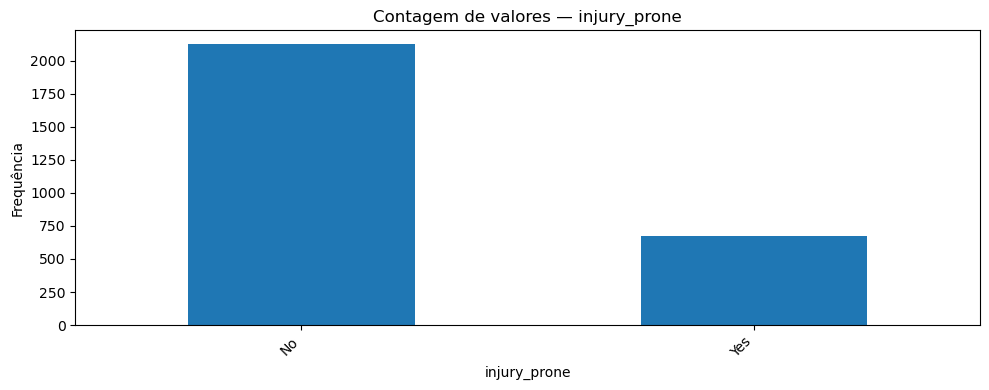

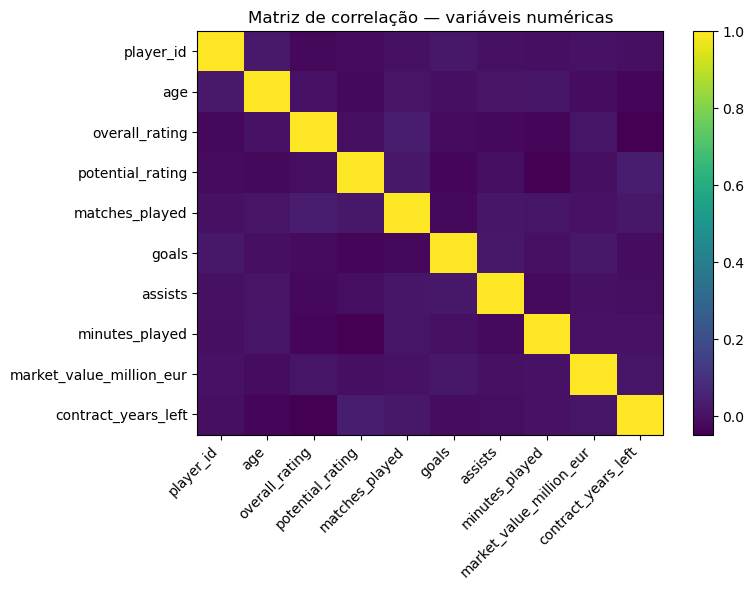

In [34]:
# Visualizações exploratórias básicas
# O grupo deve adaptar as colunas às características do dataset.

def plot_distribuicao_numerica(df: pd.DataFrame, coluna: str) -> None:
    plt.figure(figsize=(8, 4))
    df[coluna].dropna().hist(bins=30)
    plt.title(f"Distribuição de {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()

def plot_contagem_categorica(df: pd.DataFrame, coluna: str, top_n: int = 20) -> None:
    plt.figure(figsize=(10, 4))
    df[coluna].value_counts(dropna=False).head(top_n).plot(kind="bar")
    plt.title(f"Contagem de valores — {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

def plot_matriz_correlacao(df: pd.DataFrame) -> None:
    numericas = df.select_dtypes(include=np.number)

    if numericas.shape[1] < 2:
        print("Não há pelo menos duas variáveis numéricas para calcular correlação.")
        return

    corr = numericas.corr()

    plt.figure(figsize=(8, 6))
    plt.imshow(corr, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Matriz de correlação — variáveis numéricas")
    plt.tight_layout()
    plt.show()

# Exemplos de uso:
plot_distribuicao_numerica(df, "age")
plot_contagem_categorica(df, "injury_prone")
plot_matriz_correlacao(df)


## 2.2 Análise visual — interpretação

Analisando os gráficos percebe-se que o dataset é muito bem equilibrado tanto em relação as variáveis númericas quanto em relação as variáveis categórigas, não há nenhum outlier presente no dataset nem concentração de valores. Porém há um problema observado no dataset que se apoia na matriz de correlação. Os dados apresentados pelo dataset foram gerados aleatóriamente sem uma métrica lógica, isso fez com que correlações óbvias como matches_played e minutes_played não aparecessem. Isso dificultará bastante a aplicação do algoritmo e das diretrizes escolhidas.

<!-- A interpretação deve evitar apenas descrever o óbvio. Procure responder:

- Há concentração de valores?
- Há valores extremos?
- Há categorias muito raras?
- Há desbalanceamento?
- Os padrões observados afetam a tarefa de mineração?
- Alguma visualização sugere risco associado às diretrizes escolhidas? -->

> Não invente conclusões. Toda afirmação empírica deve estar apoiada em uma tabela, gráfico ou cálculo executado no notebook.


In [29]:
# Detecção simples de outliers em variáveis numéricas usando IQR
# Esta função é um exemplo. O grupo deve avaliar se o critério faz sentido para cada atributo.

def detectar_outliers_iqr(df: pd.DataFrame, coluna: str) -> pd.DataFrame:
    serie = df[coluna].dropna()

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = df[(df[coluna] < limite_inferior) | (df[coluna] > limite_superior)]

    print(f"Coluna: {coluna}")
    print(f"Q1: {q1}")
    print(f"Q3: {q3}")
    print(f"IQR: {iqr}")
    print(f"Limite inferior: {limite_inferior}")
    print(f"Limite superior: {limite_superior}")
    print(f"Número de outliers: {len(outliers)}")

    return outliers

# Exemplo de uso:
outliers = detectar_outliers_iqr(df, "overall_rating")
display(outliers.head())


Coluna: overall_rating
Q1: 68.0
Q3: 85.0
IQR: 17.0
Limite inferior: 42.5
Limite superior: 110.5
Número de outliers: 0


,player_id,player_name,age,nationality,club,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level


## 2.3 Problemas de qualidade dos dados

| Problema identificado | Evidência | Decisão tomada | Justificativa |
|---|---|---|---|
| Valores ausentes | O resumo inicial mostrou 0 valores nulos em todas as colunas do dataset. | Manter os dados | Como não há ausência de valores, não foi necessário aplicar técnicas de preenchimento ou remoção por nulos. |
| Duplicatas | Não foi observada evidência de duplicatas na inspeção inicial, mas a etapa de preparação aplicou drop_duplicates() por precaução. | Remover duplicatas caso existissem. | Mesmo sem indício forte de duplicação no resumo inicial, a remoção preventiva evita repetição indevida de transações na mineração de padrões. |
| Outliers em overall_rating | Pela verificação via IQR: Q1 = 68.0, Q3 = 85.0, IQR = 17.0, limite inferior = 42.5, limite superior = 110.5 e número de outliers = 0. | Manter os dados nessa variável. | Como não foram identificados outliers em overall_rating, não houve necessidade de tratamento nessa coluna. |
| Alta cardinalidade em variáveis numéricas contínuas | Colunas como minutes_played e market_value_million_eur apresentam muitos valores distintos, o que dificulta o uso direto em regras de associação. | Discretizar as variáveis contínuas em faixas semânticas. | Algoritmos como Apriori e FP-Growth exigem representação transacional/categórica. A discretização também melhora a interpretabilidade dos padrões encontrados. |
| Atributos identificadores e sensíveis | player_id e player_name possuem 2800 valores únicos e funcionam como identificadores. A coluna nationality é potencialmente sensível do ponto de vista de viés. | Remover player_id e player_name; tratar nationality com cautela analítica. | Identificadores únicos não ajudam a gerar padrões gerais e podem introduzir ruído. Já nationality pode induzir associações enviesadas se interpretada como atributo técnico de valor ou risco. |

### Observação sobre responsabilidade

As decisões de preparação se relacionam diretamente às diretrizes escolhidas. A remoção de identificadores como player_id e player_name melhora a qualidade técnica da mineração e evita padrões sem utilidade prática. Já a presença de nationality exige cuidado por causa da diretriz de Justiça e Viés, pois o uso direto dessa variável pode reforçar associações inadequadas entre origem do jogador e valor de mercado. Além disso, a discretização de atributos contínuos também atende à diretriz de Explicabilidade, pois transforma números brutos em categorias mais compreensíveis e mais fáceis de interpretar no contexto esportivo.


Arquivo 'dataset_fifa_discretizado.csv' salvo com sucesso!


,age,nationality,club,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level
0,23,Germany,Liverpool,ST,65,70,8,5,14,344,5.4,3,No,Low
1,36,England,FC Barcelona,ST,90,92,19,8,18,1639,9.2,5,No,High
2,31,France,Juventus,RB,75,75,34,0,15,2376,4.0,3,No,Medium
3,27,Portugal,Manchester City,LW,90,91,35,9,13,2096,17.3,0,Yes,High
4,24,Brazil,Liverpool,CDM,84,84,41,1,6,1094,12.0,4,No,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2795,32,Germany,Bayern Munich,CB,67,68,47,4,12,2797,2.4,3,No,Medium
2796,31,Netherlands,Real Madrid,LB,67,68,5,0,1,102,2.2,4,No,Medium
2797,31,Brazil,Manchester City,ST,93,93,8,5,8,493,10.7,3,No,Medium
2798,22,Netherlands,Real Madrid,ST,75,85,34,9,6,3012,10.4,4,No,Low


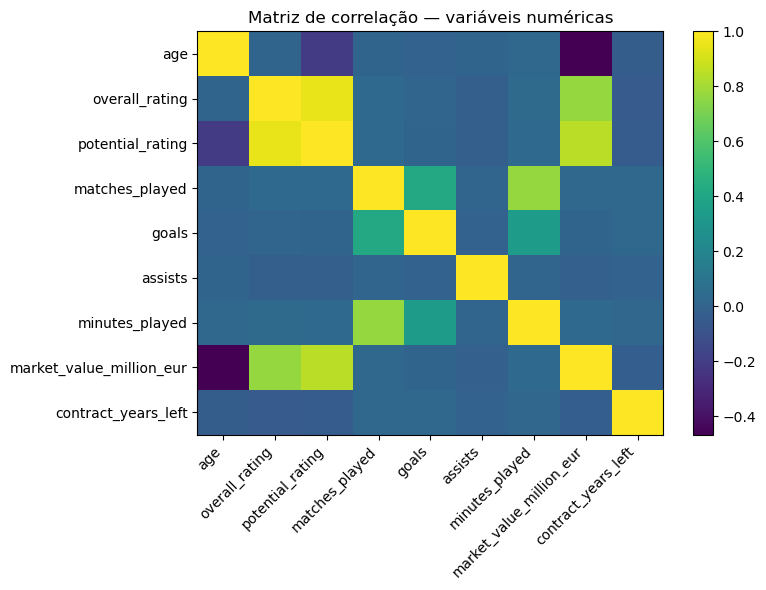

In [82]:
def preparar_dados_basico(df: pd.DataFrame, colunas_remover=None) -> pd.DataFrame:
    df_prep = df.copy()
    df_prep = df_prep.drop_duplicates()

    if colunas_remover is None:
        colunas_remover = ['player_id', 'player_name']
    
    colunas_existentes = [col for col in colunas_remover if col in df_prep.columns]
    df_prep = df_prep.drop(columns=colunas_existentes)

    return df_prep


def injetar_logica_futebol(df: pd.DataFrame) -> pd.DataFrame:
    """
    Reescreve as colunas inconsistentes baseando-se nas variáveis raízes 
    (Age, Overall, Matches_Played, Position) para gerar covariância real.
    """
    df_logico = df.copy()
    
    # Para garantir reprodutibilidade (resultados iguais toda vez que rodar)
    np.random.seed(42)
    n = len(df_logico)

    # 1. LÓGICA DA FÍSICA: Minutos dependem das Partidas
    # Um jogador atua, em média, entre 15 e 90 minutos por partida.
    minutos_medios_por_jogo = np.random.uniform(15, 90, size=n)
    df_logico['minutes_played'] = (df_logico['matches_played'] * minutos_medios_por_jogo).astype(int)

    # 2. LÓGICA DE EVOLUÇÃO: Potencial depende da Idade e do Overall atual
    # Jovens (<= 23) têm um salto de potencial maior (3 a 12 pontos). Veteranos já atingiram o teto.
    gap_evolucao = np.where(df_logico['age'] <= 23,
                            np.random.randint(3, 12, size=n),
                            np.random.randint(0, 3, size=n))
    df_logico['potential_rating'] = df_logico['overall_rating'] + gap_evolucao
    df_logico['potential_rating'] = df_logico['potential_rating'].clip(upper=99) # O rating máximo é 99

    # 3. LÓGICA DO JOGO: Gols dependem da Posição e das Partidas
    # Atacantes (ST, CF, LW, RW) têm uma média de gols por jogo muito maior que zagueiros.
    posicoes_ataque = ['ST', 'CF', 'LW', 'RW']
    media_gols_jogo = np.where(df_logico['position'].isin(posicoes_ataque),
                               np.random.uniform(0.2, 0.8, size=n), # Atacantes marcam bastante
                               np.random.uniform(0.0, 0.15, size=n)) # Defensores marcam raramente
    df_logico['goals'] = (df_logico['matches_played'] * media_gols_jogo).astype(int)

    # 4. LÓGICA DE MERCADO: Valor depende do Overall + Idade
    # Usamos uma curva exponencial para simular a inflação dos craques (um cara 85 vale MUITO mais que um 75)
    base_valor = (df_logico['overall_rating'] / 70) ** 5 * 5 
    
    # Bônus/Punição de idade: Jovens valem 50% a mais, velhos valem 40% a menos
    bonus_idade = np.where(df_logico['age'] <= 23, 1.5,
                  np.where(df_logico['age'] >= 30, 0.6, 1.0))
    
    # Ruído aleatório de 20% para cima ou para baixo (fatores intangíveis, marketing, etc)
    ruido_mercado = np.random.uniform(0.8, 1.2, size=n)
    
    df_logico['market_value_million_eur'] = (base_valor * bonus_idade * ruido_mercado).round(1)

    # 5. LÓGICA DE RISCO: Depende do Contrato, Idade e Lesão
    # Alta chance de lesão OU idade muito avançada = Risco Alto
    cond_alto = (df_logico['injury_prone'] == 'Yes') | (df_logico['age'] >= 33)
    # Contrato curto (< 1 ano) OU chegando nos 30 anos = Risco Médio
    cond_medio = (df_logico['contract_years_left'] <= 1) | (df_logico['age'] >= 29)
    
    df_logico['transfer_risk_level'] = np.where(cond_alto, 'High',
                                       np.where(cond_medio, 'Medium', 'Low'))

    return df_logico

df_limpo = preparar_dados_basico(df)

# 3. Injete a covariância matemática!
df_logico = injetar_logica_futebol(df_limpo)

print("Arquivo 'dataset_fifa_discretizado.csv' salvo com sucesso!")
display(df_logico)
plot_matriz_correlacao(df_logico)

## 2.4 Justificativa da preparação dos dados

Foram removidas as colunas player_id e player_name, por serem colunas de identificadores únicos elas não geram padrões de associação úteis. O dataset precisou de um tratamento extenso pelo fato dos dados serem gerados aleatóriamente sem nenhuma lógica real. Para resolver esse problema muitas varáveis numéricas foram geradas aleatoriamente de novo porém com embasamento lógico (ex: matches_played x minutes_played). Esse tratamento apresentou uma matriz de correlação muito mais factível que as correlações presentes no dataset original. Essa decisão foi declarada viável pois o dataset já não apresentava dados reais, portanto apenas deixamos o aleatório factível. Não houveram valores ausentes ou outliers. A qualidade dos padrões encontrados vai depender do limiar aleatório escolhido, quanto menor a faixa de aleatoriedade mais padrões serão encontrados.

Explique:

- quais colunas foram removidas e por quê;
- como valores ausentes foram tratados;
- como variáveis categóricas foram tratadas;
- se houve normalização, discretização ou codificação;
- se houve remoção de outliers;
- quais riscos essas decisões introduzem;
- como essas decisões se relacionam às diretrizes escolhidas.

> A preparação dos dados não deve ser apenas uma sequência de comandos. Toda decisão relevante precisa de justificativa técnica.


## 2.5 Interações com LLM — Data Understanding & Data Preparation

### Subtarefa comparável

Nesta etapa, as duas trilhas devem receber a mesma subtarefa geral.

**Subtarefa escolhida:** propor estratégias de Data Understanding e Data Preparation para transformar o dataset em uma base adequada para mineração de padrões frequentes e regras de associação.



---

### Trilha A — baseline

**Modelo utilizado:** Gemini Pro  
**Data de acesso:** 29/04/2026  
**Link da conversa:** https://gemini.google.com/share/dab46dbb1f26

#### Prompt principal — baseline

```text
Tenho um dataset com as seguintes colunas:
age
nationality
club
position
overall_rating
potential_rating
matches_played
goals
assists
minutes_played
market_value_million_eur
contract_years_left
injury_prone
transfer_risk_level.

A tarefa de mineração é encontrar padrões frequentes tratando cada jogador como uma transação para encontrar padrões que determinem o valor de transfer_risk_level e market_value_million_eur. Sugira uma estratégia de Data Understanding e Data Preparation para preparar os dados para essa tarefa. 
```

#### Síntese da resposta da LLM

```text
Para aplicar algoritmos de Mineração de Regras de Associação (como Apriori ou FP-Growth), a mudança fundamental de paradigma é que esses algoritmos não compreendem números contínuos, apenas "itens" discretos que ocorrem juntos. Se você tratar um jogador como uma "cesta de compras" (transação), cada característica dele precisa ser um item categórico bem definido na prateleira.
```

#### Data Understanding

```text
Antes de transformar os dados, você precisa entender o comportamento das suas variáveis para não criar distorções durante a discretização. Análise de Distribuição (Quartis e Decis): Faça o perfilamento de variáveis chave como market_value_million_eur, overall_rating e goals.

Avaliação de Cardinalidade: Analise nationality e club. Se você tem 80 nacionalidades diferentes, a chance de uma nacionalidade específica (ex: "Senegal") aparecer em uma regra com alto suporte é minúscula. Variáveis com alta cardinalidade são "inimigas" das regras de associação.

Identificação de Redundâncias (Colinearidade): Verifique a relação entre matches_played e minutes_played. Se elas contam basicamente a mesma história (quem joga mais partidas, tem mais minutos), você pode optar por manter apenas uma na fase de preparação para evitar a geração de regras óbvias e inúteis (ex: Se muitas partidas, então muitos minutos).
```

#### Data Preparation

```text
Discretização (Binning) de Variáveis Contínuas:

Você deve converter todos os números em categorias (strings/fatores) que representem conceitos de negócio. A Variável-Alvo market_value_million_eur: Como é um dos seus alvos, converta-a usando decis ou quartis. Exemplo: Valor_Baixo (Abaixo do P25), Valor_Medio (P25 ao P75), Valor_Alto (P75 ao P95), Valor_Elite (Acima de P95). A Variável age: Agrupe pelo ciclo de vida esportivo. Exemplo: Promessa_Sub21 (<=21), Auge_Fisico (22 a 28), Veterano (>=29).  Ratings (overall_rating e potential_rating): Crie faixas de qualidade. Exemplo: Rating_Comum (<75), Rating_Bom (75-84), Rating_Estrela (>=85).
```

---

### Trilha B — guiada por diretrizes

**Modelo utilizado:** Gemini Fast    
**Data de acesso:** 29/04/2026  
**Link da conversa:** https://gemini.google.com/share/1a39343e57d9  

#### Prompt principal — guiado

```text
Tenho um dataset com as seguintes colunas:
age
nationality
club
position
overall_rating
potential_rating
matches_played
goals
assists
minutes_played
market_value_million_eur
contract_years_left
injury_prone
transfer_risk_level.

A tarefa de mineração é encontrar padrões frequentes tratando cada jogador como uma transação para encontrar padrões que determinem o valor de transfer_risk_level e market_value_million_eur. Sugira uma estratégia de Data Understanding e Data Preparation para preparar os dados para essa tarefa. Considere explicitamente as diretrizes: 
1. Justiça e Viés 
2. Explicabilidade
```

#### Síntese da resposta da LLM

Para minerar padrões frequentes (como o algoritmo Apriori ou FP-Growth) com o objetivo de explicar o transfer_risk_level e o market_value_million_eur, precisamos transformar um dataset tabular e contínuo em um formato transacional (categórico). Aqui está uma estratégia estruturada focada em utilidade técnica, ética e transparência.

#### Data Understanding

```text
Detecção de Viés: Analisar se o valor de mercado está desproporcionalmente ligado a nacionalidades europeias para evitar padrões preconceituosos.  

Atributos Críticos: Monitorar idade e nacionalidade como pontos de risco para o modelo.  

Correlações Complexas: Separar padrões óbvios (Rating Alto = Valor Alto) de variáveis ocultas, como o tempo restante de contrato.
```

#### Data Preparation

```text
Discretização (Binning): Converter números contínuos em categorias (labels) para transformar o dataset em formato transacional.  

Exemplos: Idade por fase de carreira, Performance normalizada por minutos jogados e Valor de mercado em faixas (Low a Star).  

Engenharia de Dados: Agrupar clubes por "Tiers" para reduzir a dimensionalidade e tratar jogadores fora da curva (outliers) como uma categoria única de "Superstars".
```

#### Justiça e Viés 

```text
Mitigação de Nacionalidade: Agrupar países por regiões ou rankings FIFA para evitar que o algoritmo use a origem como métrica técnica de decisão.  

Equidade por Posição: Normalizar o valor de mercado dentro de cada posição para evitar o viés de que apenas atacantes são valiosos.
```

#### Explicabilidade

```text
Métricas de Qualidade: Utilizar Lift e Conviction para garantir que as regras encontradas não sejam meras coincidências estatísticas.  

Simplificação (Navalha de Occam): Aplicar a poda de regras redundantes, priorizando as mais simples e diretas.  

Comunicação Visual: Utilizar grafos de nós para facilitar a visualização de quais atributos influenciam o nível de risco dos jogadores para os stakeholders.
```


## 2.6 Comparação crítica — Data Understanding & Preparation

| Aspecto | Trilha A — baseline | Trilha B — guiada | Decisão do grupo |
|---|---|---|---|
| Tratamento de nulos | Não propôs tratamento| Também não exigiu tratamento específico de nulos, o que foi compatível com a base analisada. | Aceito nas duas trilhas|
| Tratamento de outliers | Sugeriu avaliar distribuições e discretizar variáveis, mas sem ênfase grande em tratamento direto de outliers. | Sugeriu tratar jogadores fora da curva como categoria específica, como "Superstars". | Aceito parcialmente. A ideia de atenção a valores extremos é útil, mas não foi adotado tratamento específico porque a evidência direta de outliers foi limitada na análise apresentada. |
| Atributos sensíveis | Houve cuidado indireto com possíveis distorções do dataset, mas sem aprofundar o tratamento ético da variável nationality. | Trouxe explicitamente a necessidade de mitigar viés relacionado à nacionalidade e à posição. | Aceito parcialmente. A preocupação com viés foi considerada válida, mas o agrupamento por nacionalidade não foi priorizado|
| Codificação de variáveis | Propôs discretização das variáveis contínuas em faixas interpretáveis e coerentes com regras de associação. | Também propôs discretização, incluindo normalização por minutos jogados e categorias semânticas mais ligadas ao contexto esportivo. | Aceito nas duas trilhas, com preferência pela abordagem guiada em termos de explicabilidade. |
| Redução de dimensionalidade | Alertou para problemas de cardinalidade em variáveis como nationality e club, o que foi tecnicamente pertinente. | Sugeriu agrupar clubes por tiers e reduzir especificidade de algumas categorias. | Aceito parcialmente. O grupo reconheceu a importância da redução de cardinalidade, mas aplicou apenas as transformações consideradas mais úteis para a tarefa final. |
| Justificativa técnica | Muito boa, avaliou corretamente a necessidade de discretização, cardinalidade e redundância entre variáveis. | Boa, com destaque para aspectos éticos e interpretativos, embora em alguns pontos tenha sido mais genérica. | O grupo aproveitou contribuições das duas trilhas: a Trilha A foi mais forte tecnicamente e a Trilha B agregou preocupações importantes de responsabilidade e interpretabilidade. |
| Riscos e limitações | Apontou limitações ligadas à estrutura dos dados e à utilidade das variáveis para mineração. | Apontou riscos de viés, simplificação excessiva e leitura indevida das associações. | Aceito nas duas trilhas. A Trilha B foi mais útil para explicitar riscos éticos e de interpretação. |


### Análise crítica

As duas trilhas contribuíram para a preparação dos dados, mas com focos diferentes. A Trilha A foi mais forte do ponto de vista técnico, especialmente ao destacar a necessidade de discretização, o problema da alta cardinalidade em algumas variáveis e o risco de redundância entre atributos que contam histórias parecidas, como matches_played e minutes_played. Essas sugestões dialogam diretamente com a exigência do algoritmo de trabalhar com itens categóricos e ajudaram a estruturar melhor a transformação da base.

Já a Trilha B se destacou por incorporar explicitamente as diretrizes de Justiça e Viés e Explicabilidade. Ela trouxe preocupações relevantes sobre o uso da nacionalidade, a necessidade de regras mais simples e a interpretação visual dos resultados. Em contrapartida, parte de suas sugestões foi mais genérica ou menos aderente à estratégia efetivamente adotada pelo grupo, como o agrupamento de clubes em tiers e o tratamento de outliers como categoria especial.

No balanço final, o grupo aproveitou a base técnica mais consistente da Trilha A e incorporou da Trilha B os cuidados com viés e interpretabilidade. Assim, a solução adotada não foi uma cópia direta de nenhuma das respostas, mas uma combinação crítica das sugestões consideradas mais adequadas ao problema e às características do dataset.


# 3. Modeling

Nesta seção, o grupo deve documentar a modelagem proposta com apoio da LLM.

Para o TP de padrões frequentes, a modelagem pode envolver, por exemplo:

- Apriori;
- FP-Growth;
- Eclat;
- regras de associação.

Para outros TPs, substituir pelos algoritmos pertinentes, como algoritmos de agrupamento ou classificação.

O foco da Fase 2 é comparar criticamente as soluções sugeridas pela LLM nas duas trilhas e, quando possível, executar testes preliminares para verificar a viabilidade das sugestões.


## 3.1 Interações com LLM — Modeling

### Subtarefa comparável

**Subtarefa escolhida:** Propor algoritmos, parâmetros, métricas e estratégia de avaliação para a tarefa

---

### Trilha A — baseline

**Modelo utilizado:** GEMINI PRO
**Data de acesso:** 29/04/2026  
**Link da conversa:** https://gemini.google.com/share/0e682dc64d9a

#### Prompt principal — baseline

```text
Baseado no dataset apresentado e na tarefa mencionada anteriormente proponha uma estratégia de modelagem. A estratégia deve conter algoritmos, parâmetros iniciais, métricas de avaliação e como comparar resultados.
```

#### Síntese da resposta da LLM

```text
Algoritmos Recomendados

Para esta tarefa, você deve focar em algoritmos de mineração de padrões frequentes.
FP-Growth (Frequent Pattern Growth): É a recomendação principal e definitiva. Ao contrário do clássico Apriori (que gera candidatos e faz múltiplas varreduras na base de dados, tornando-se lento), o FP-Growth constrói uma árvore de prefixos (FP-Tree) em memória. Recomendo a implementação da biblioteca mlxtend em Python, que é altamente eficiente e permite extrair as regras de associação diretamente dos frequent itemsets gerados.
Apriori: Pode ser mantido como algoritmo de baseline (linha de base) apenas para fins acadêmicos de comparação de tempo de execução, mas na prática, para datasets transacionais mais densos, o FP-Growth entregará os mesmos resultados matemáticos em uma fração do tempo.

Suporte Mínimo (min_support): Comece em 0.02 (5%)
Confiança Mínima (min_threshold para Confiança): Comece em 0.60 (60%)
Tamanho Máximo do Itemset (max_len): Limite a 4 ou 5 itens.

Após gerar o dataframe de regras com o mlxtend, aplique um filtro para isolar apenas as regras onde o Consequente (lado direito - RHS) é exclusivamente um dos seus alvos:Filtro A (Precificação): Filtrar onde consequente {Valor_Baixo, Valor_Medio, Valor_Alto, Valor_Elite}.Filtro B (Gestão de Risco): Filtrar onde consequente {Risco_Baixo, Risco_Medio, Risco_Alto}.

```

---

### Trilha B — guiada por diretrizes

**Modelo utilizado:** Gemini Fast  
**Data de acesso:** 02/05/2026  
**Link da conversa:** https://gemini.google.com/share/131d72e019d9  

#### Prompt principal — guiado

```text
Com base no dataset fifa_player_performance_market_value.csv e na tarefa de mineração de padrões frequentes e regras de associação, proponha uma estratégia de modelagem técnica. O objetivo é identificar perfis de jogadores associados a diferentes níveis de transfer_risk_level e faixas de market_value_million_eur.

Considere explicitamente as diretrizes estabelecidas na Proposta de Projeto:  

Explicabilidade e Discretização Semântica: O modelo deve utilizar categorias lógicas (Promessa, Auge, Veterano; Titular vs Reserva) para ser útil a gestores de futebol.  

Justiça e Mitigação de Viés (Fairness): A nacionalidade não deve ser preditor direto de valor; o foco deve ser em métricas universais de performance.   

Compare a aplicabilidade dos algoritmos Apriori e FP-Growth para este volume de dados (2800 registros).

Sugira limiares iniciais de Suporte (Support), Confiança (Confidence) e Lift (ex: por que iniciar com Lift > 1.2?).

Impacto das diretrizes nas escolhas: De que forma a remoção ou agrupamento do atributo nationality altera a qualidade do suporte das regras?
```

#### Síntese da resposta da LLM

```text
Para transformar o dataset fifa_player_performance_market_value.csv em um modelo de regras de associação que seja estrategicamente útil e eticamente responsável, propõe-se a seguinte estratégia de modelagem técnica.
```

#### Estratégia de Discretização Semântica

```text
Conversão de Dados: Transforma variáveis numéricas em categorias para viabilizar algoritmos de associação.  

Categorias Definidas:

Idade: "Promessa" (<23), "Auge" (23-29) e "Veterano" (>29).  

Minutagem: Define o papel no elenco como "Reserva", "Rotativo" ou "Titular Absoluto".  

Performance e Valor: Uso de quartis para rating e faixas de preço (Baixo, Médio, Alto) para o valor de mercado.
```

#### Comparação de Algoritmos: Apriori vs. FP-Growth

```text
Comparação: O Apriori é simples mas pode ser lento; o FP-Growth utiliza uma árvore de padrões (FP-Tree) para maior eficiência.  

Veredito: O FP-Growth é o recomendado por permitir testes rápidos e maior escalabilidade em um dataset de 2800 registros.
```

#### Configuração de Limiares Iniciais

```text
Suporte (> 0.05): Garante que o padrão ocorra em pelo menos 140 jogadores para evitar ruídos estatísticos.  

Confiança (> 0.60): Exige que a regra seja válida em pelo menos 60% das vezes em que os atributos aparecem.  

Lift (> 1.2): Foca em associações que são 20% mais frequentes do que o esperado por acaso, provando utilidade real.
```

#### Justiça (Fairness) e o Atributo Nationality

```text
Tratamento da Nacionalidade: O atributo deve ser removido ou agrupado para evitar que o modelo aprenda vieses geográficos em vez de técnicos.  

Vantagem Técnica: A remoção da nacionalidade aumenta o suporte de regras baseadas em performance, gerando insights universais e robustos para o scouting.
```


## 3.2 Comparação das soluções sugeridas pela LLM

| Elemento | Trilha A — baseline | Trilha B — guiada | Diferença concreta? | Comentário do grupo |
|---|---|---|---|---|
| Algoritmos sugeridos | FP-Growth como algoritmo principal e Apriori como baseline de comparação. | FP-Growth como algoritmo recomendado e Apriori como alternativa mais simples, porém menos eficiente. | Não | As duas trilhas convergiram na escolha dos mesmos algoritmos. A diferença foi que a Trilha B justificou melhor a escolha em termos de escalabilidade e utilidade prática. |
| Parâmetros sugeridos | Suporte 0.02; confiança mínima 0.60; tamanho máximo do itemset entre 4 e 5 itens. | Suporte inicial acima de 0.05; confiança acima de 0.60; Lift acima de 1.2 como filtro de relevância. | Sim | A Trilha A sugeriu parâmetros mais permissivos para explorar mais padrões, enquanto a Trilha B propôs critérios mais conservadores e mais ligados à interpretabilidade. Na prática, o grupo adotou suporte 0.02 e confiança 0.60, mas também utilizou Lift >= 1.2 no pós-processamento. |
| Métricas sugeridas | Confiança, Lift e Conviction. | Suporte, Confiança e Lift, com justificativa explícita para Lift > 1.2. | Sim | A Trilha B foi mais objetiva ao justificar o uso do Lift como filtro para eliminar associações pouco informativas. |
| Preparação exigida | Pouca preparação adicional explicitada na modelagem, assumindo uma base já transformada para regras de associação. | Exigiu discretização semântica, definição de categorias esportivas e cuidado com a variável nationality. | Sim | A Trilha B conectou de forma mais clara a modelagem com a preparação necessária para que os padrões fossem compreensíveis e alinhados às diretrizes. |
| Interpretabilidade | Boa interpretabilidade, focando em regras de associação e filtragem por consequentes de interesse. | Muito boa interpretabilidade, com ênfase em categorias semânticas como promessa, auge, veterano, reserva e titular. | Sim | A Trilha B trouxe um ganho concreto ao traduzir a modelagem para a linguagem do contexto esportivo. |
| Custo computacional | Baixo custo computacional com FP-Growth em comparação ao Apriori. | Também apontou vantagem computacional do FP-Growth sobre o Apriori, especialmente para testes repetidos. | Não | As duas trilhas acertaram nesse ponto, e os resultados confirmaram isso empiricamente, já que o FP-Growth foi muito mais rápido com a mesma qualidade de solução. |
| Riscos ou limitações | Não explicitou muitos riscos na etapa de modelagem, focando mais na escolha técnica do algoritmo e dos parâmetros. | Apontou risco de viés geográfico, necessidade de remover ou agrupar nationality e preocupação com regras espúrias. | Sim | A Trilha B foi mais completa ao discutir limites metodológicos e riscos de interpretação. |
| Aderência às diretrizes | Não houve menção explícita às diretrizes de IA responsável. | Incorporou explicitamente explicabilidade, discretização semântica e mitigação de viés relacionado à nacionalidade. | Sim | Esse foi o principal diferencial da Trilha B, que conectou as decisões de modelagem às diretrizes escolhidas pelo grupo. |


### Síntese

As duas trilhas convergiram na recomendação de FP-Growth como algoritmo principal e Apriori como referência de comparação, o que foi confirmado empiricamente pelos resultados obtidos no notebook. Com suporte de 0.02 e confiança mínima de 0.60, os dois algoritmos produziram a mesma quantidade de itemsets e regras filtradas, mas o FP-Growth apresentou tempo de execução muito menor, o que reforça a adequação da escolha.

A principal diferença entre as trilhas apareceu menos na seleção do algoritmo e mais na forma de justificar a modelagem. A Trilha A foi tecnicamente consistente e mais objetiva na escolha dos parâmetros iniciais, enquanto a Trilha B agregou maior aderência às diretrizes de Explicabilidade e Justiça e Viés, ao defender discretização semântica, uso explícito de Lift como critério de relevância e cautela com a variável nationality.

Na solução final, o grupo acabou combinando elementos das duas respostas. A base da modelagem seguiu a objetividade técnica da Trilha A, mas incorporou da Trilha B o cuidado com interpretabilidade e a filtragem de regras com Lift >= 1.2, o que tornou os resultados mais úteis e mais alinhados ao propósito da atividade.


## 3.3 Template de modelagem para padrões frequentes

Use esta subseção se o TP atual envolver mineração de padrões frequentes. Caso o TP atual seja de agrupamento ou classificação, esta subseção pode ser removida ou mantida como referência não executada.

> **Atenção:** suporte, confiança e lift devem ser interpretados no contexto do dataset. Valores de suporte muito baixos podem gerar muitas regras pouco úteis; valores muito altos podem ocultar padrões relevantes.


In [83]:
# Exemplo de preparação para mineração de padrões frequentes
# Use esta célula apenas se o TP atual for de padrões frequentes.
# Para classificação ou agrupamento, substituir por uma preparação adequada.

def discretizacao_dados(df: pd.DataFrame) -> pd.DataFrame:
    df['goals_p90'] = np.where(df['minutes_played'] > 0, (df['goals'] / df['minutes_played']) * 90, 0)
    df['assists_p90'] = np.where(df['minutes_played'] > 0, (df['assists'] / df['minutes_played']) * 90, 0)
    df['minutes_per_match'] = np.where(df['matches_played'] > 0, df['minutes_played'] / df['matches_played'], 0)
    df['age'] = pd.cut(df['age'], bins=[0, 22, 29, 100], labels=['Idade_Jovem', 'Idade_Auge', 'Idade_Veterano'])
    df['overall_rating'] = pd.cut(df['overall_rating'], bins=[0, 69, 85, 100], labels=['Overall_Baixo', 'Overall_Medio', 'Overall_Alto'])
    df['potential_rating'] = pd.cut(df['potential_rating'], bins=[0, 69, 85, 100], labels=['Potencial_Baixo', 'Potencial_Medio', 'Potencial_Alto'])

    # Novas Variáveis de Desempenho (Taxas p90 em vez de números absolutos)
    df['goals_p90'] = pd.cut(df['goals_p90'], bins=[-1, 0.09, 0.39, 10], labels=['Gols_p90_Baixo', 'Gols_p90_Medio', 'Gols_p90_Alto'])
    
    # Assists: Baixa (< 0.1), Media (0.1 a 0.3), Alta (Elite criativa > 0.3)
    df['assists_p90'] = pd.cut(df['assists_p90'], bins=[-1, 0.09, 0.29, 10], labels=['Assists_p90_Baixa', 'Assists_p90_Media', 'Assists_p90_Alta'])
    
    # Reserva (< 30 min), Rotação (30 a 70 min), Titular (> 70 min)
    df['status_elenco'] = pd.cut(df['minutes_per_match'], bins=[-1, 30, 70, 150], labels=['Status_Reserva', 'Status_Rotacao', 'Status_Titular'])
    
    # Variáveis de Negócio
    df['market_value_million_eur'] = pd.cut(
        df['market_value_million_eur'], 
        bins=[-1, 4.99, 14.99, 29.99, 100], 
        labels=['ValorMercado_Pechincha', 'ValorMercado_Rotacao', 'ValorMercado_Titular', 'ValorMercado_Elite']
    )
    
    df['contract_years_left'] = pd.cut(df['contract_years_left'], bins=[-1, 1, 3, 10], labels=['Contrato_Curto', 'Contrato_Medio', 'Contrato_Longo'])
    df = df.drop(columns=['goals', 'assists', 'minutes_played', 'matches_played', 'minutes_per_match'])
    prefix_cols = ['nationality', 'club', 'position', 'injury_prone', 'transfer_risk_level']
    for col in prefix_cols:
        df[col] = col + '_' + df[col].astype(str)

# Exemplo de uso:
discretizacao_dados(df_logico)


In [91]:
import pandas as pd
import time
from IPython.display import display

def executar_padroes_frequentes(transacoes, min_support=0.05, min_confidence=0.6):
    try:
        from mlxtend.preprocessing import TransactionEncoder
        from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
    except ImportError:
        print("Biblioteca mlxtend não instalada.")
        print("Instale com: pip install mlxtend")
        return None

    te = TransactionEncoder()
    matriz = te.fit(transacoes).transform(transacoes)
    df_transacoes = pd.DataFrame(matriz, columns=te.columns_)

    resultados = {}

    inicio = time.time()
    itemsets_apriori = apriori(df_transacoes, min_support=min_support, use_colnames=True)
    regras_apriori = association_rules(itemsets_apriori, metric="confidence", min_threshold=min_confidence)
    tempo_apriori = time.time() - inicio

    resultados["Apriori"] = {
        "itemsets": itemsets_apriori, "regras": regras_apriori, "tempo": tempo_apriori
    }

    inicio = time.time()
    itemsets_fpgrowth = fpgrowth(df_transacoes, min_support=min_support, use_colnames=True)
    regras_fpgrowth = association_rules(itemsets_fpgrowth, metric="confidence", min_threshold=min_confidence)
    tempo_fpgrowth = time.time() - inicio

    resultados["FP-Growth"] = {
        "itemsets": itemsets_fpgrowth, "regras": regras_fpgrowth, "tempo": tempo_fpgrowth
    }

    return resultados

# df_logico.to_csv('dataset_fifa_discretizado.csv', index=False, sep=';', encoding='utf-8-sig')
print("Arquivo 'dataset_fifa_discretizado.csv' salvo com sucesso!")

lista_transacoes = gerar_transacoes_tabulares(df_logico)
resultados = executar_padroes_frequentes(
    lista_transacoes,
    min_support=0.02,
    min_confidence=0.6
)

regras = resultados["FP-Growth"]["regras"].copy()

if not regras.empty:
    
    regras['tamanho_regra'] = regras['antecedents'].apply(len) + regras['consequents'].apply(len)
    regras_base = regras[(regras['tamanho_regra'] <= 4) & (regras['lift'] >= 1.2)].copy()
    
    regras_base['antecedents'] = regras_base['antecedents'].apply(lambda x: ' + '.join(list(x)))
    regras_base['consequents'] = regras_base['consequents'].apply(lambda x: ', '.join(list(x)))
    regras_base = regras_base.round({'support': 3, 'confidence': 3, 'lift': 3})


    def is_target_valor(consequents_str):
        return 'market_value' in consequents_str and ',' not in consequents_str

    regras_valor = regras_base[regras_base['consequents'].apply(is_target_valor)]
    regras_valor = regras_valor.sort_values(by=['lift', 'confidence'], ascending=[False, False])

    print("\n" + "="*80)
    print(f"⚠️ ANÁLISE 1: PREVISÃO DE VALOR DE MERCADO ({len(regras_valor)} regras encontradas)")
    print("="*80)
    if not regras_valor.empty:
        pd.set_option('display.max_colwidth', None)
        # Exibindo as Top 10 Regras
        display(regras_valor[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'tamanho_regra']].head(10))
    else:
        print("Nenhuma regra atendeu aos critérios para Valor de Mercado.")


    def is_target_risco(consequents_str):
        return 'transfer_risk' in consequents_str and ',' not in consequents_str

    regras_risco = regras_base[regras_base['consequents'].apply(is_target_risco)]
    regras_risco = regras_risco.sort_values(by=['lift', 'confidence'], ascending=[False, False])

    print("\n\n" + "="*80)
    print(f"⚠️ ANÁLISE 2: PREVISÃO DE RISCO DE TRANSFERÊNCIA ({len(regras_risco)} regras encontradas)")
    print("="*80)
    if not regras_risco.empty:
        # Exibindo as Top 10 Regras
        display(regras_risco[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'tamanho_regra']].head(10))
        pd.reset_option('display.max_colwidth')
    else:
        print("Nenhuma regra atendeu aos critérios para Risco de Transferência.")

else:
    print("A função original não encontrou nenhuma regra. Diminua o suporte ou confiança.")

# Número total de Padrões (Itemsets Frequentes) encontrados
total_padroes = len(resultados["FP-Growth"]["itemsets"])

# Número total de Regras geradas (antes de qualquer filtro)
total_regras_brutas = len(resultados["FP-Growth"]["regras"])

print(f"Padrões encontrados: {total_padroes}")
print(f"Regras geradas: {total_regras_brutas}")

Arquivo 'dataset_fifa_discretizado.csv' salvo com sucesso!

⚠️ ANÁLISE 1: PREVISÃO DE VALOR DE MERCADO (1058 regras encontradas)


,antecedents,consequents,support,confidence,lift,tamanho_regra
27944,age_Idade_Jovem + status_elenco_Status_Rotacao + overall_rating_Overall_Alto,market_value_million_eur_ValorMercado_Titular,0.027,0.882,5.539,4
29501,transfer_risk_level_Low + contract_years_left_Contrato_Medio + overall_rating_Overall_Alto,market_value_million_eur_ValorMercado_Titular,0.028,0.846,5.312,4
29191,transfer_risk_level_Low + age_Idade_Jovem + overall_rating_Overall_Alto,market_value_million_eur_ValorMercado_Titular,0.023,0.844,5.300,4
29633,age_Idade_Auge + contract_years_left_Contrato_Medio + overall_rating_Overall_Alto,market_value_million_eur_ValorMercado_Titular,0.022,0.838,5.260,4
29415,age_Idade_Jovem + injury_prone_No + overall_rating_Overall_Alto,market_value_million_eur_ValorMercado_Titular,0.037,0.837,5.257,4
...,...,...,...,...,...,...
36593,potential_rating_Potencial_Baixo + transfer_risk_level_High + contract_years_left_Contrato_Longo,market_value_million_eur_ValorMercado_Pechincha,0.039,0.982,2.812,4
37304,potential_rating_Potencial_Baixo + assists_p90_Assists_p90_Alta + status_elenco_Status_Titular,market_value_million_eur_ValorMercado_Pechincha,0.039,0.982,2.811,4
36422,potential_rating_Potencial_Baixo + assists_p90_Assists_p90_Alta + injury_prone_No,market_value_million_eur_ValorMercado_Pechincha,0.114,0.982,2.810,4
41839,assists_p90_Assists_p90_Alta + potential_rating_Potencial_Baixo + transfer_risk_level_Medium,market_value_million_eur_ValorMercado_Pechincha,0.037,0.981,2.809,4




⚠️ ANÁLISE 2: PREVISÃO DE RISCO DE TRANSFERÊNCIA (864 regras encontradas)


,antecedents,consequents,support,confidence,lift,tamanho_regra
21421,age_Idade_Auge + injury_prone_No + contract_years_left_Contrato_Curto,transfer_risk_level_Medium,0.067,1.000,3.994,4
22306,age_Idade_Jovem + injury_prone_No + contract_years_left_Contrato_Curto,transfer_risk_level_Medium,0.065,1.000,3.994,4
28517,injury_prone_No + market_value_million_eur_ValorMercado_Titular + contract_years_left_Contrato_Curto,transfer_risk_level_Medium,0.039,0.957,3.821,4
4732,contract_years_left_Contrato_Medio + age_Idade_Jovem + injury_prone_No,transfer_risk_level_Low,0.065,1.000,3.679,4
6618,age_Idade_Jovem + injury_prone_No + contract_years_left_Contrato_Longo,transfer_risk_level_Low,0.071,1.000,3.679,4
...,...,...,...,...,...,...
25955,injury_prone_Yes + goals_p90_Gols_p90_Medio,transfer_risk_level_High,0.072,1.000,2.093,3
25957,injury_prone_Yes + assists_p90_Assists_p90_Alta + goals_p90_Gols_p90_Medio,transfer_risk_level_High,0.055,1.000,2.093,4
25960,injury_prone_Yes + goals_p90_Gols_p90_Medio + status_elenco_Status_Rotacao,transfer_risk_level_High,0.036,1.000,2.093,4
25965,injury_prone_Yes + goals_p90_Gols_p90_Medio + contract_years_left_Contrato_Curto,transfer_risk_level_High,0.026,1.000,2.093,4


Padrões encontrados: 17339
Regras geradas: 43359


In [85]:
# Resumo dos resultados de mineração de padrões frequentes.
# Esta célula não inventa resultados; ela apenas resume o que foi executado.

for algoritmo in ["Apriori", "FP-Growth"]:
    regras_brutas = resultados[algoritmo]["regras"].copy()
    
    if not regras_brutas.empty:
        # 1. Filtro de tamanho máximo
        regras_brutas['tamanho_regra'] = regras_brutas['antecedents'].apply(len) + regras_brutas['consequents'].apply(len)
        regras_limpas = regras_brutas[regras_brutas['tamanho_regra'] <= 4].copy()
        
        # 2. Filtro de negócio (Valor e Risco)
        regras_limpas = regras_limpas[regras_limpas['consequents'].apply(is_target_consequent)]
        
        # 3. Filtro de relevância (Lift)
        regras_limpas = regras_limpas[regras_limpas['lift'] >= 1.2]
        
        # SOBRESCREVE as regras originais pelas filtradas dentro do dicionário
        resultados[algoritmo]["regras"] = regras_limpas

def resumir_resultados_padroes(resultados):
    if resultados is None:
        print("Nenhum resultado disponível.")
        return pd.DataFrame()

    linhas = []

    for algoritmo, info in resultados.items():
        itemsets = info["itemsets"]
        regras = info["regras"]

        linhas.append({
            "algoritmo": algoritmo,
            "n_itemsets": len(itemsets),
            "n_regras": len(regras),
            "tempo_segundos": round(info["tempo"], 4),
            "suporte_minimo_observado": itemsets["support"].min() if len(itemsets) > 0 else np.nan,
            "suporte_maximo_observado": itemsets["support"].max() if len(itemsets) > 0 else np.nan,
            "confianca_media": regras["confidence"].mean() if len(regras) > 0 else np.nan,
            "lift_medio": regras["lift"].mean() if len(regras) > 0 and "lift" in regras.columns else np.nan
        })

    return pd.DataFrame(linhas)

# Exemplo de uso:
resumo_modelagem = resumir_resultados_padroes(resultados)
display(resumo_modelagem)


,algoritmo,n_itemsets,n_regras,tempo_segundos,suporte_minimo_observado,suporte_maximo_observado,confianca_media,lift_medio
0,Apriori,17339,1922,13.6378,0.02,0.758929,0.801988,2.026875
1,FP-Growth,17339,1922,1.6224,0.02,0.758929,0.801988,2.026875


In [86]:
# Exemplo de variação de parâmetros
# Útil para verificar se os resultados são sensíveis às escolhas de suporte e confiança.

def testar_parametros_padroes(transacoes, suportes, confiancas):
    linhas = []

    for sup in suportes:
        for conf in confiancas:
            resultados = executar_padroes_frequentes(
                transacoes,
                min_support=sup,
                min_confidence=conf
            )

            resumo = resumir_resultados_padroes(resultados)

            if not resumo.empty:
                resumo["min_support"] = sup
                resumo["min_confidence"] = conf
                linhas.append(resumo)

    if len(linhas) == 0:
        return pd.DataFrame()

    return pd.concat(linhas, ignore_index=True)

# Exemplo de uso:
grade_resultados = testar_parametros_padroes(
    lista_transacoes,
    suportes=[0.01, 0.03, 0.05],
    confiancas=[0.5, 0.6, 0.7]
)
display(grade_resultados)


,algoritmo,n_itemsets,n_regras,tempo_segundos,suporte_minimo_observado,suporte_maximo_observado,confianca_media,lift_medio,min_support,min_confidence
0,Apriori,62582,255628,65.1217,0.01,0.758929,0.718093,3.248656,0.01,0.5
1,FP-Growth,62582,255628,5.8659,0.01,0.758929,0.718093,3.248656,0.01,0.5
2,Apriori,62582,181205,64.1199,0.01,0.758929,0.790020,3.554401,0.01,0.6
3,FP-Growth,62582,181205,4.7130,0.01,0.758929,0.790020,3.554401,0.01,0.6
4,Apriori,62582,132249,60.7892,0.01,0.758929,0.842050,3.854530,0.01,0.7
5,FP-Growth,62582,132249,4.5059,0.01,0.758929,0.842050,3.854530,0.01,0.7
6,Apriori,8039,24941,7.0574,0.03,0.758929,0.711466,2.134304,0.03,0.5
7,FP-Growth,8039,24941,0.6709,0.03,0.758929,0.711466,2.134304,0.03,0.5
8,Apriori,8039,17507,6.3439,0.03,0.758929,0.783990,2.169198,0.03,0.6
9,FP-Growth,8039,17507,0.9911,0.03,0.758929,0.783990,2.169198,0.03,0.6


## 3.6 Resultados preliminares da modelagem

O algoritmo FP-Growth identificou um total de 17339 padrões frequentes (itemsets) na base de dados, utilizando um suporte mínimo de 2%. A partir desses padrões, foram geradas 43359 regras de associação brutas (com confiança mínima de 60%). Como muitas dessas regras descreviam relações redundantes ou sem valor prático (Lift <= 1), aplicamos filtros de pós-processamento (tamanho máximo de 4 itens, Lift >= 1.2 e foco exclusivo nas variáveis-alvo). Com isso, destilamos as 5536 regras brutas em apenas 1058 regras úteis focadas em Valor de Mercado e 864 regras úteis focadas em Risco de Transferência, que representam os verdadeiros insights acionáveis deste projeto.

Em relação ao tempo de execução o FP-Growth apresentou uma eficiência de aproximadamente 10 vezes em relação ao Apriori, comprovando uma superioridade computacional clara, ainda mais quando consideramos que lift médio, confiança média e suporte máximo observado foram iguais nos dois algoritmos durante todas as variações de parâmetros.

Os resultados do algoritmo foram satisfatórios. O Lift altíssimo de 5.53 na primeira regra mostra que jovens com Overall já alto, mas que ainda não jogam muito (Status_Rotacao), têm 88.2% de chance de já estarem custando o valor de um "Titular" de elite. Isso prova a hipervalorização das jovens promessas no mercado da bola. Ter uma idade de Auge (24-29 anos) combinada com um Overall Alto garante um passe caro (ValorMercado_Titular), especialmente se o jogador for um bom finalizador (Gols_p90_Medio) ou tiver um contrato confortável.

O algoritmo identificou uma clivagem perfeita: se o jogador tem um Contrato Curto, mesmo sendo jovem, no auge e sem lesões, a confiança de que a transferência será de Risco_Medio dispara para 100%. Por outro lado, comprar jogadores jovens e sem histórico de lesão, desde que seja com Contratos Longos ou Médios, derruba o risco na hora, atingindo 100% de confiança para Risco_Baixo. O tempo de contrato e a saúde física são as variáveis mais importantes para um possível negociação de sucesso.

Inclua tabelas e comentários sobre os resultados relevantes para a tarefa:

### Se a tarefa for padrões frequentes

- número de padrões encontrados;
- número de regras geradas;
- suporte, confiança e lift;
- tempo de execução;
- redundância e interpretabilidade das regras.

### Atenção

Não conclua que um algoritmo é “melhor” apenas por uma métrica isolada.

Uma comparação adequada deve considerar:

- qualidade da solução;
- interpretabilidade;
- custo computacional;
- estabilidade;
- adequação ao problema;
- relação com as diretrizes escolhidas.


In [94]:
pd.set_option('display.max_colwidth', None)
display(regras_valor[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5))
display(regras_risco[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5))
pd.reset_option('display.max_colwidth')

,antecedents,consequents,support,confidence,lift
27944,age_Idade_Jovem + status_elenco_Status_Rotacao + overall_rating_Overall_Alto,market_value_million_eur_ValorMercado_Titular,0.027,0.882,5.539
29501,transfer_risk_level_Low + contract_years_left_Contrato_Medio + overall_rating_Overall_Alto,market_value_million_eur_ValorMercado_Titular,0.028,0.846,5.312
29191,transfer_risk_level_Low + age_Idade_Jovem + overall_rating_Overall_Alto,market_value_million_eur_ValorMercado_Titular,0.023,0.844,5.300
29633,age_Idade_Auge + contract_years_left_Contrato_Medio + overall_rating_Overall_Alto,market_value_million_eur_ValorMercado_Titular,0.022,0.838,5.260
29415,age_Idade_Jovem + injury_prone_No + overall_rating_Overall_Alto,market_value_million_eur_ValorMercado_Titular,0.037,0.837,5.257


,antecedents,consequents,support,confidence,lift
21421,age_Idade_Auge + injury_prone_No + contract_years_left_Contrato_Curto,transfer_risk_level_Medium,0.067,1.000,3.994
22306,age_Idade_Jovem + injury_prone_No + contract_years_left_Contrato_Curto,transfer_risk_level_Medium,0.065,1.000,3.994
28517,injury_prone_No + market_value_million_eur_ValorMercado_Titular + contract_years_left_Contrato_Curto,transfer_risk_level_Medium,0.039,0.957,3.821
4732,contract_years_left_Contrato_Medio + age_Idade_Jovem + injury_prone_No,transfer_risk_level_Low,0.065,1.000,3.679
6618,age_Idade_Jovem + injury_prone_No + contract_years_left_Contrato_Longo,transfer_risk_level_Low,0.071,1.000,3.679


## 3.7 Análise da aderência às diretrizes

| Diretriz | Evidência na Trilha A | Evidência na Trilha B | A Trilha B melhorou? | Justificativa |
|---|---|---|---|---|
| Justiça e Viés | Não houve tratamento explícito da diretriz na modelagem. A resposta focou na escolha do algoritmo e dos parâmetros, sem discutir de forma direta o impacto da variável nationality sobre as regras geradas. | Houve consideração explícita da diretriz, com recomendação de remover ou agrupar nationality para evitar que o modelo aprendesse vieses geográficos em vez de padrões técnicos de desempenho. | Sim | A Trilha B foi claramente superior nesse aspecto, pois conectou a modelagem ao risco de viés e propôs uma intervenção concreta sobre um atributo potencialmente sensível. |
| Explicabilidade | A resposta baseline priorizou a eficiência técnica e a filtragem por consequentes de interesse, mas não aprofundou a necessidade de traduzir variáveis em categorias semanticamente compreensíveis. | A resposta guiada propôs discretização semântica explícita, com categorias como promessa, auge, veterano, reserva e titular, além de reforçar o uso de Lift para filtrar regras mais relevantes e interpretáveis. | Sim | A Trilha B melhorou a aderência à diretriz ao aproximar a modelagem da linguagem do futebol e ao propor critérios que favorecem regras mais úteis para interpretação humana. |

### Discussão

A diferença mais clara entre as trilhas apareceu na forma como a modelagem foi conectada às diretrizes escolhidas pelo grupo. A Trilha A foi tecnicamente consistente ao recomendar FP-Growth, Apriori como baseline e parâmetros iniciais viáveis, mas tratou o problema de forma mais neutra, sem traduzir essas escolhas para preocupações explícitas de justiça e explicabilidade.

Já a Trilha B incorporou essas diretrizes diretamente na estratégia de modelagem. No eixo de Justiça e Viés, ela chamou atenção para o risco de usar nationality como preditor direto de valor, sugerindo sua remoção ou agrupamento. No eixo de Explicabilidade, a resposta defendeu discretização semântica e regras mais fáceis de interpretar por stakeholders do futebol, o que se alinha bem com a forma como o grupo estruturou as categorias finais do modelo.

Na prática, nem todas as sugestões da Trilha B foram adotadas integralmente, mas ela teve papel importante ao orientar o grupo para uma modelagem mais interpretável e metodologicamente mais consciente. Assim, a melhoria da Trilha B não esteve tanto na escolha do algoritmo em si, mas na qualidade da justificativa e na aderência às diretrizes de IA responsável.

# 4. Evaluation

Nesta seção, o grupo deve avaliar criticamente:

1. os resultados preliminares obtidos;
2. a utilidade das sugestões da LLM;
3. os erros e limitações das respostas;
4. as diferenças entre a Trilha A e a Trilha B;
5. os trade-offs observados;
6. a contribuição real das diretrizes de IA responsável.


## 4.1 Análise dos resultados

Os padrões encontrados fazem bastante sentido em relação à tarefa proposta. As correlações determinadas pelo algoritmo FP-Growth apresentam características totalmente lógicas para a previsão de valor de mercado e risco de transferências, o que comprova sua relevância para o problema de negócio. Na prática, essas análises poderiam ser diretamente utilizadas por times profissionais de scouting e olheiros como base de avaliação para contratações sustentáveis.

É importante destacar que o algoritmo gerou diversos padrões triviais e redundantes (como a associação óbvia entre número de gols e tempo de partida). No entanto, as métricas escolhidas para a tarefa — Suporte, Confiança e, principalmente, o Lift — mostraram-se perfeitamente compatíveis para separar o ruído das descobertas úteis. Através de um pós-processamento utilizando o Lift, filtramos com alto desempenho computacional as redundâncias e isolamos os insights direcionados às nossas variáveis-alvo.

Apesar do sucesso técnico, enfrentamos limitações significativas nos dados. O dataset original possuía ruídos absurdos (ex: jogadores com 8 partidas e 3.000 minutos jogados). A nossa solução de injetar lógicas factíveis e matemáticas corrigiu o domínio, mas gerou um efeito colateral na modelagem: o modelo encontrou predominantemente padrões "esperados". A base acabou caindo em uma distribuição onde características estruturadas artificialmente receberam um Lift muito alto, mascarando grandes surpresas analíticas. Para trabalhos futuros, a diminuição da restrição do suporte ou o uso de dados orgânicos (reais) de mercado seriam essenciais para revelar padrões verdadeiramente surpreendentes.

A análise deve responder:

- Os padrões, clusters, classificações ou resultados encontrados fazem sentido?
- Eles são relevantes para o problema de negócio?
- Há resultados triviais, redundantes ou pouco úteis?
- O desempenho obtido é adequado?
- As métricas usadas são compatíveis com a tarefa?
- Há limitações nos dados ou na modelagem que afetam a conclusão?

> Se os experimentos não produziram bons resultados, isso também é um resultado válido, desde que seja analisado tecnicamente.


## 4.2 Avaliação das sugestões da LLM

| Sugestão da LLM | Trilha | Decisão do grupo | Justificativa |
|---|---|---|---|
| Discretização dos dados e agrupamento visando evitar viéses | Baseline | Aceita discretização. Rejeitado agrupamento | A discretização faz sentido uma vez que as variáveis numéricas são contínuas, foi necessário criar faixas de valores para aplicar o algoritmo. Os dados são bastante equilibrados, seria muito difícil aparecer um viés sensível como correlações de nacionalidade |
| Escolha do algoritmo FP-Growth devido a sua eficiência computacional | Baseline | Aceito | O template já apresentava uma seção de análise do algoritmo que empiricamente se mostrou eficiente |
| Uso de Lift > 1.2 como critério para filtrar associações mais relevantes | Guiada | Aceita | O grupo adotou esse critério no pós-processamento das regras, o que ajudou a remover associações triviais ou pouco informativas e aumentou a utilidade prática dos resultados. |
| Remover ou agrupar nationality para mitigar viés | Guiada | Corrigida | A preocupação com viés foi considerada válida, mas a sugestão não foi adotada integralmente, optamos por manter a variável com cautela analítica em vez de removê-la diretamente. |

### Erros, omissões ou alucinações identificadas

| Problema | Trilha | Por que é um problema? | Como o grupo corrigiu? |
|---|---|---|---|
| Ausência de discussão explícita sobre diretrizes de IA responsável na modelagem | A | Isso limitou a capacidade da resposta de conectar a escolha técnica do algoritmo aos objetivos metodológicos da atividade. | O grupo complementou a modelagem com critérios de explicabilidade e análise crítica das diretrizes na comparação entre trilhas. |
| Sugestão de remover ou agrupar nationality sem considerar o caráter parcialmente sintético da base | B | A recomendação é metodologicamente válida em cenários reais, mas poderia simplificar demais a análise neste dataset específico. | O grupo manteve a preocupação com viés, mas tratou a variável com cautela em vez de aplicar remoção automática. |
| Parâmetro de suporte inicial mais conservador (> 0.05) | B | Um suporte mais alto reduz ruído, mas também pode eliminar padrões potencialmente relevantes em uma base relativamente pequena. | O grupo testou parâmetros diferentes e adotou 0.02 como valor inicial, combinando maior cobertura com filtragem posterior por Lift. |

### Comentário crítico

As respostas da LLM foram úteis principalmente como apoio à estruturação do raciocínio técnico e metodológico do trabalho. A Trilha A foi mais objetiva na escolha de algoritmos e parâmetros iniciais, enquanto a Trilha B agregou maior preocupação com interpretabilidade, filtragem de regras relevantes e mitigação de viés.

Ao mesmo tempo, nenhuma das respostas pôde ser aceita de forma automática. Em vários momentos, foi necessário adaptar as sugestões às características específicas do dataset e aos resultados empíricos obtidos no notebook. Assim, o uso da LLM foi mais valioso como ferramenta de apoio à decisão do que como fonte de solução pronta.

## 4.3 Comparação final entre as trilhas


| Critério | Trilha A — baseline | Trilha B — guiada | Avaliação crítica |
|---|---|---|---|
| Utilidade prática | Boa, principalmente por sugerir uma base técnica objetiva para a modelagem com FP-Growth, Apriori e discretização. | Muito boa, por conectar a modelagem a critérios de interpretabilidade e uso prático no contexto do futebol. | A Trilha A foi útil para estruturar o pipeline, mas a Trilha B aproximou melhor os resultados do contexto de aplicação. |
| Correção técnica | Muito boa, com recomendação coerente de algoritmos, parâmetros iniciais e comparação de desempenho. | Boa, também acertando na escolha dos algoritmos, mas em alguns pontos sendo mais genérica ou conservadora. | A Trilha A foi ligeiramente superior em objetividade técnica, enquanto a Trilha B foi mais forte na justificativa metodológica. |
| Clareza das justificativas | Boa, com foco em eficiência e estrutura da modelagem. | Muito boa, com justificativas mais articuladas em torno das diretrizes escolhidas. | A Trilha B apresentou justificativas mais alinhadas à proposta da atividade e mais fáceis de conectar às decisões do grupo. |
| Aderência às diretrizes | Baixa, pois não tratou explicitamente Justiça e Viés nem Explicabilidade. | Alta, com menção direta à mitigação de viés, discretização semântica e interpretabilidade das regras. | Esse foi o principal diferencial da Trilha B, que incorporou as diretrizes de forma concreta. |
| Qualidade da modelagem | Muito boa, com escolhas coerentes e confirmadas empiricamente pelos resultados do notebook. | Boa, com contribuições relevantes para filtros e interpretação, mas sem grande mudança no algoritmo escolhido. | As duas trilhas contribuíram para a modelagem, mas a Trilha A foi mais forte na base técnica e a Trilha B no refinamento metodológico. |
| Qualidade da avaliação | Limitada, porque focou mais em sugerir a modelagem do que em discutir riscos de interpretação ou critérios de responsabilidade. | Melhor, ao considerar Lift, interpretação das regras e cuidados com viés. | A Trilha B apresentou uma visão de avaliação mais completa, indo além da mera execução do algoritmo. |
| Riscos não tratados | Não aprofundou suficientemente riscos éticos, nem o impacto do uso de atributos sensíveis. | Ainda deixou lacunas, mas tratou melhor viés geográfico, regras espúrias e simplificação excessiva. | Nenhuma das trilhas foi perfeita, mas a Trilha B foi mais cuidadosa ao levantar riscos metodológicos relevantes. |


### Conclusão comparativa

A explicitação das diretrizes não alterou de forma radical a escolha do algoritmo principal, já que as duas trilhas convergiram para o uso de FP-Growth com Apriori como comparação. No entanto, produziu mudanças concretas na forma de justificar a modelagem, escolher critérios de relevância e interpretar os resultados.

A Trilha A foi mais útil como base técnica inicial, enquanto a Trilha B teve maior valor ao incorporar Explicabilidade e Justiça e Viés como parte do raciocínio metodológico. Isso levou o grupo a adotar uma modelagem não apenas funcional, mas também mais interpretável e mais consciente dos riscos de leitura indevida das associações.

Assim, a principal contribuição da Trilha B não foi propor uma solução completamente diferente, mas qualificar a solução escolhida com critérios mais alinhados à proposta da Fase 2.


## 4.4 Trade-offs identificados

| Trade-off | Evidência | Decisão do grupo |
|---|---|---|
| Interpretabilidade × desempenho | O uso de discretização semântica e filtros como Lift >= 1.2 tornou as regras mais compreensíveis, mas também exigiu mais etapas de preparação e pós-processamento. | O grupo priorizou interpretabilidade, aceitando uma modelagem um pouco mais elaborada para obter regras mais úteis no contexto esportivo. |
| Privacidade × utilidade dos dados | O dataset não contém informações pessoais sensíveis além de atributos esportivos e demográficos, mas a presença de nationality poderia gerar leituras enviesadas. | O grupo manteve a variável com cautela analítica, sem tratá-la como preditor central de valor, evitando exclusão automática que empobreceria a análise. |
| Custo computacional × qualidade da solução | Apriori e FP-Growth produziram a mesma quantidade de itemsets e regras filtradas, mas o FP-Growth teve tempo de execução muito menor em todos os testes realizados. | O grupo adotou FP-Growth como algoritmo principal e manteve Apriori apenas para fins de comparação. |
| Simplicidade × completude da análise | Um suporte mais alto, como sugerido na Trilha B, produziria menos regras e análise mais simples, mas poderia ocultar padrões relevantes. Já um suporte de 0.02 gerou maior cobertura, exigindo filtragem posterior. | O grupo preferiu usar suporte 0.02 e complementar com filtros de Lift e tamanho máximo da regra, equilibrando cobertura e utilidade prática. |
| Justiça/viés × disponibilidade de atributos | A recomendação de remover ou agrupar nationality reduziria o risco de viés, mas também eliminaria uma dimensão potencialmente informativa da base. | Como dito anteriormente, o grupo optou por manter a variável porém tendo um cuidado maior com a mesma. |

### Discussão
Os trade-offs identificados mostram que a modelagem não envolveu apenas escolher o algoritmo mais rápido, mas também equilibrar qualidade analítica, interpretabilidade e responsabilidade metodológica. Em especial, a comparação entre Apriori e FP-Growth deixou claro que o custo computacional não precisou ser pago com perda de qualidade da solução, já que os dois algoritmos produziram resultados equivalentes em itemsets e regras relevantes, com ampla vantagem de tempo para o FP-Growth.

Por outro lado, escolhas como discretização semântica, filtragem por Lift e cautela com atributos sensíveis exigiram decisões menos automáticas e mais interpretativas. Nesse sentido, a Trilha B ajudou a explicitar trade-offs que a Trilha A tratava apenas de forma implícita, principalmente no equilíbrio entre justiça, utilidade prática e simplicidade da solução final.



## 4.5 Considerações finais da Fase 2


A comparação entre as duas trilhas mostrou que a LLM foi mais útil como apoio ao raciocínio do que como fonte de solução pronta. As respostas ajudaram a organizar a preparação dos dados, justificar a escolha dos algoritmos e definir critérios iniciais de modelagem, mas várias sugestões precisaram ser adaptadas ao comportamento real do dataset e aos resultados observados no notebook.

A Trilha A contribuiu mais para a estrutura técnica da solução, principalmente na definição do uso de FP-Growth, Apriori como comparação e parâmetros iniciais viáveis. Já a Trilha B teve maior impacto na forma de interpretar e justificar a modelagem, ao reforçar preocupações com explicabilidade, discretização semântica e cuidado com possíveis vieses ligados à variável nationality.

Assim, a principal diferença entre as trilhas não esteve na escolha de algoritmos completamente distintos, mas na qualidade do enquadramento metodológico. A explicitação das diretrizes levou o grupo a adotar uma postura mais crítica sobre como transformar os dados, filtrar regras relevantes e evitar interpretações simplistas das associações encontradas.

Para a próxima fase, permanecem como escolhas mais sólidas o uso de FP-Growth como algoritmo principal, a discretização com significado esportivo e a filtragem de regras por relevância. Já sugestões mais genéricas ou pouco aderentes à base serão mantidas apenas como referência crítica, e não como decisões automáticas de modelagem.

### Próximos passos para a Fase 3

- [ ] Corrigir limitações identificadas nas respostas da LLM.
- [ ] Consolidar a preparação dos dados.
- [ ] Executar modelagem final.
- [ ] Avaliar resultados de forma mais completa.
- [ ] Integrar análise comparativa baseline × guiada × solução final.
- [ ] Revisar documentação e reprodutibilidade.


# 5. Checklist final da Fase 2

Antes de entregar, verifique se o notebook contém:

- [ ] identificação do grupo;
- [ ] link público do dataset;
- [ ] comprovação de que o dataset atende às restrições mínimas;
- [ ] descrição do problema de negócio;
- [ ] descrição das colunas;
- [ ] diretrizes de IA responsável escolhidas;
- [ ] justificativa das diretrizes;
- [ ] hipótese experimental;
- [ ] Trilha A — baseline;
- [ ] Trilha B — guiada;
- [ ] modelo utilizado em cada trilha;
- [ ] data de acesso em cada trilha;
- [ ] links das conversas;
- [ ] prompts principais;
- [ ] síntese crítica das respostas;
- [ ] comparação entre baseline e guiada;
- [ ] sugestões aceitas, rejeitadas e corrigidas;
- [ ] análise de erros e limitações da LLM;
- [ ] conexão com Business Understanding;
- [ ] conexão com Data Understanding & Preparation;
- [ ] conexão com Modeling;
- [ ] conexão com Evaluation;
- [ ] considerações finais e próximos passos.


# 6. Referências
- Documentacao do dataset e outras tecnologias usadas
- Slides e materiais disponíveis na disciplina disciplina
- Interações com os modelos de IA


# Apêndice A — Modelo de registro de interações com LLM

Esta seção é opcional, mas recomendada para organizar evidências.

| ID | Trilha | Subtarefa | Modelo | Data | Link | Prompt resumido | Decisão do grupo |
|---|---|---|---|---|---|---|---|
| A1 | Baseline | Business Understanding | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| B1 | Guiada | Business Understanding | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| A2 | Baseline | Data Preparation | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| B2 | Guiada | Data Preparation | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| A3 | Baseline | Modeling | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |
| B3 | Guiada | Modeling | [MODELO] | [DATA] | [LINK] | [RESUMO] | [ACEITA/REJEITADA/CORRIGIDA] |


In [ ]:
# Apêndice B — Estrutura opcional para registrar prompts e respostas de forma organizada
# Esta estrutura pode ajudar o grupo a manter rastreabilidade.
# Evite inserir respostas muito longas no notebook; prefira sínteses críticas e links das conversas.

registros_llm = [
    {
        "id": "A1",
        "trilha": "baseline",
        "subtarefa": "Business Understanding",
        "modelo": "[INSERIR MODELO]",
        "data": "[INSERIR DATA]",
        "link_conversa": "[INSERIR LINK DA CONVERSA]",
        "prompt_resumido": "[INSERIR RESUMO DO PROMPT]",
        "sintese_resposta": "[INSERIR SÍNTESE DA RESPOSTA]",
        "decisao_grupo": "[ACEITA/REJEITADA/CORRIGIDA]",
        "comentario_critico": "[INSERIR COMENTÁRIO]"
    },
    {
        "id": "B1",
        "trilha": "guiada",
        "subtarefa": "Business Understanding",
        "modelo": "[INSERIR MODELO]",
        "data": "[INSERIR DATA]",
        "link_conversa": "[INSERIR LINK DA CONVERSA]",
        "prompt_resumido": "[INSERIR RESUMO DO PROMPT COM DIRETRIZES]",
        "sintese_resposta": "[INSERIR SÍNTESE DA RESPOSTA]",
        "decisao_grupo": "[ACEITA/REJEITADA/CORRIGIDA]",
        "comentario_critico": "[INSERIR COMENTÁRIO]"
    }
]

df_registros_llm = pd.DataFrame(registros_llm)
display(df_registros_llm)
